## Imports and Environment Setup

In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
    
import sys, os
import numpy as np
import healpy as hp
from scipy.stats import chi2
import matplotlib
matplotlib.rcParams.update({'font.size':20})
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from pylab import rcParams
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble']
rcParams['axes.facecolor'] = 'white'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/sptlocal/user/kevinlevy/summerfield_lensing/notebooks/apjfonts}')
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u

In [2]:
def logrebincl(ell,cl, Nbins=None, minell=None, maxell=None, bins=None, wl=None):
    ''' rebin cls in logspace '''
    if bins is None:
        bb = np.logspace(np.log10(minell),np.log10(maxell),Nbins+1)
        ll = (bb[:-1]).astype(np.int_)+1
        uu = (bb[1:]).astype(np.int_)
    else:
        ll = bins[0] 
        uu = bins[1] 
        Nbins = len(bins[0])
    ret  = np.zeros(Nbins)
    retl = np.zeros(Nbins)
    var  = np.zeros(Nbins)
    
    if wl is None:
        wl = np.ones(len(cl))
   
    for i in range(0,Nbins):
        ret[i]  = np.sum(wl[ll[i]:uu[i]]*cl[ll[i]:uu[i]])/np.sum(wl[ll[i]:uu[i]])   #np.mean(cl[ll[i]:uu[i]])
        retl[i] = np.sum(wl[ll[i]:uu[i]]*ell[ll[i]:uu[i]])/np.sum(wl[ll[i]:uu[i]])  #np.mean(ell[ll[i]:uu[i]])
        var[i] = np.std(cl[ll[i]:uu[i]])

    return retl,ret,var


def chi2_pte_combined(data_dic, model_fid, cov_dic, A_best):
    """
    Compute chi2 and PTE for combined lensing amplitude with full covariance matrices.

    Parameters
    ----------
    data_dic : dict
        Measured lensing spectra per field.
    model_fid : array
        Fiducial theoretical spectrum.
    cov_dic : dict
        Covariance matrices per field.
    A_best : float
        Best-fit lensing amplitude.

    Returns
    -------
    chi2_tot : float
        Total chi-squared.
    dof : int
        Degrees of freedom.
    PTE : float
        Probability to exceed.
    """

    # Stack data, model, and covariance
    data_all = np.concatenate([data_dic[k] for k in data_dic.keys()])
    model_all = np.concatenate([model_fid for k in data_dic.keys()])  # same fiducial for all fields

    # Block-diagonal covariance
    cov_all = np.block([
        [cov_dic[k] if i==j else np.zeros_like(cov_dic[k])
         for j,k in enumerate(cov_dic.keys())]
        for i,k in enumerate(cov_dic.keys())
    ])

    residual = data_all - A_best * model_all
    cov_inv = np.linalg.inv(cov_all)
    chi2_tot = residual @ cov_inv @ residual

    dof = len(data_all) - 1  # 1 fitted parameter
    PTE = 1 - chi2.cdf(chi2_tot, dof)

    return chi2_tot, dof, PTE


def combine_lensing_amplitude(data_dic, model_fid, err_dic=None, cov_dic=None):
    """
    Compute the combined best-fit lensing amplitude across multiple fields using a fiducial spectrum.

    Parameters
    ----------
    data_dic : dict
        Dictionary of measured lensing spectra per field.
        Example: {'summer-a': array([...]), 'summer-b': array([...])}
    model_fid : array
        Theoretical fiducial lensing spectrum (same for all fields).
    err_dic : dict, optional
        Dictionary of 1-sigma errors per field (for diagonal covariance). Example: {'summer-a': array([...]), ...}
        Required if cov_dic is None.
    cov_dic : dict, optional
        Dictionary of full covariance matrices per field. Example: {'summer-a': array([...]), ...}
        Overrides err_dic if provided.

    Returns
    -------
    A_best : float
        Combined best-fit lensing amplitude.
    A_err : float
        1-sigma uncertainty on the combined amplitude.
    """

    numerator = 0.0
    denominator = 0.0

    for key in data_dic.keys():
        data = np.array(data_dic[key])
        
        if cov_dic is not None:
            cov = np.array(cov_dic[key])
            cov_inv = np.linalg.inv(cov)
            numerator += model_fid @ cov_inv @ data
            denominator += model_fid @ cov_inv @ model_fid
        else:
            sigma2 = np.array(err_dic[key])**2
            weights = 1.0 / sigma2
            numerator += np.sum(weights * data * model_fid)
            denominator += np.sum(weights * model_fid**2)
    
    A_best = numerator / denominator
    A_err = np.sqrt(1.0 / denominator)
    return A_best, A_err


Lmax=2498
nsims = 198
nsims_unlensed = 148
field_arr = ["summer-a", "summer-b", "summer-c"]

Nbins=12
minell=50
maxell=2000

arcmin = (1/60)*(np.pi/180)
clkk_theory = np.load('clkk_theory.npy')[:Lmax]
_,clkkb_theory, _ =logrebincl(np.arange(len(clkk_theory)), clkk_theory, Nbins, minell, maxell)
nside = 2048
ell = np.arange(Lmax)


ra_deg = 51
dec_deg = -37
radius_deg = 1.5
theta = np.radians(90 - dec_deg)  # colatitude
phi   = np.radians(ra_deg)
vec = hp.ang2vec(theta, phi)
pix1 = hp.query_disc(nside, vec, np.radians(radius_deg))

ra_deg = 73
dec_deg = -43
radius_deg = 3
theta = np.radians(90 - dec_deg)  # colatitude
phi   = np.radians(ra_deg)
vec = hp.ang2vec(theta, phi)
pix2 = hp.query_disc(nside, vec, np.radians(radius_deg))

apod_mask_dic = {}
for field in field_arr:
    apod_mask = hp.read_map('/sptlocal/user/kevinlevy/summerfield_lensing/data/masks/border_mask_%s.fits'%(field)) 
    if field == 'summer-a':
        apod_mask[pix1] = 1 
        apod_mask[pix2] = 1
    apod_mask[apod_mask == hp.UNSEEN] = None
    apod_mask[apod_mask == 0] = None
    apod_mask_dic[field] = apod_mask

baseline_dic = {}
for field in field_arr:
    baseline_dir = '/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/' %(field) 
    baseline_dic[field] = baseline_dir

unlensed_dic = {}
for field in field_arr:
    unlensed_dir = '/sptlocal/user/kevinlevy/summerfield_lensing/healqest/lensrec/unlensed_lmin500lmax3500mmin100_%s/sqe/' %(field)
    unlensed_dic[field] = unlensed_dir

leftright_dic = {}
for field in field_arr:
    leftright_dic[field] = '/sptlocal/user/kevinlevy/summerfield_lensing/healqest/lensrec/leftright_lmin500lmax3500mmin100_%s/sqe/' %(field)

lmin_alt1_dic = {}
for field in field_arr:
    lmin_alt1_dic[field] = '/sptlocal/user/kevinlevy/summerfield_lensing/healqest/lensrec/lensrec_lmin350lmax3000mmin100_%s/sqe/' %(field)

lmin_alt2_dic = {}
for field in field_arr:
    lmin_alt2_dic[field] = '/sptlocal/user/kevinlevy/summerfield_lensing/healqest/lensrec/lensrec_lmin750lmax3000mmin100_%s/sqe/' %(field)

lmax_alt1_dic = {}
for field in field_arr:
     lmax_alt1_dic[field] = '/sptlocal/user/kevinlevy/summerfield_lensing/healqest/lensrec/lensrec_lmin500lmax2500mmin100_%s/sqe/' %(field)

lmax_alt2_dic = {}
for field in field_arr:
    lmax_alt2_dic[field] = '/sptlocal/user/kevinlevy/summerfield_lensing/healqest/lensrec/lensrec_lmin500lmax3500mmin100_%s/sqe/' %(field)

mmin_alt_dic = {}
for field in field_arr:
    mmin_alt_dic[field] = '/sptlocal/user/kevinlevy/summerfield_lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin300_%s/sqe/' %(field)


title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
labelsize = 17
legendsize = 15
color_arr = ['steelblue', 'goldenrod', 'lightseagreen', 'black', 'dimgray']  


nbr_pix_dic = {"summer-a":[3100, 1750], "summer-b":[3100, 1750], "summer-c":[3100, 1750]}
cntr_dic = {"summer-a":[75, -46.75], "summer-b":[25, -36], "summer-c":[187.5, -38.5]}  
ra_dic = {'summer-a':[50, 62.5, 75, 87.5, 100], 
          'summer-b':[0, 12.5, 25, 37.5, 50], 
          'summer-c':[150, 168.75, 187.5, 206.25, 225]}
dec_dic = {'summer-a':[-63,-56, -49, -42, -35.875, -31.375, -28.125],            
           'summer-b':[-42, -38.5, -35, -31.5, -28], 
           'summer-c':[-42, -38.5, -35, -31.5, -28]}

reso_arcmin = 1.45 #hp.nside2resol(2048, arcmin = True)
origin_arr = ['lower', 'lower', 'lower']
log_offset = 1.03 
figures_dir = '/sptlocal/user/kevinlevy/summerfield_lensing/figures/lensrec/'

## Responses

In [3]:
avgmcresp_dic = {}
mcresp_N1_dic = {}

for field in field_arr:
    aresp = np.load(baseline_dic[field]+'aresp/aresp_lminT500_lmaxT3000.npz')['TT']
    avgmcresp = np.load(baseline_dic[field]+'plms/respavgTT.npz')['resp']/(aresp)
    avgmcresp_dic[field] = avgmcresp

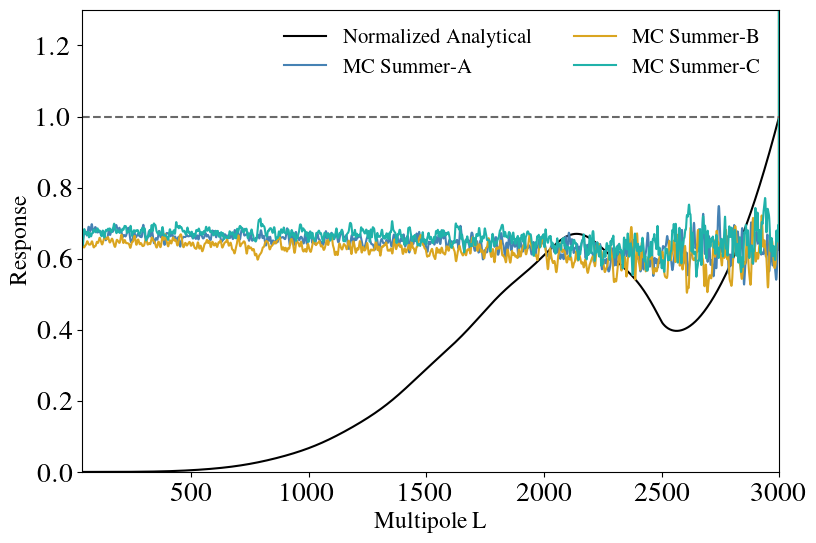

In [4]:
fig, ax = plt.subplots(figsize = (9,6))
ax.plot(aresp/np.max(aresp), color =  color_arr[-2], label='Normalized Analytical')
for i, field in enumerate(field_arr):
    ax.plot(avgmcresp_dic[field], color = color_arr[i], label='MC %s' %(title_dic[field]))
    
ax.axhline(1, color=color_arr[-1], ls = '--')
ax.set_ylabel('Response', fontsize=labelsize)
ax.set_xlabel('Multipole L', fontsize=labelsize)
ax.set_ylim(0.,1.3)
ax.set_xlim(3.5e1, 3e3)
ax.legend(prop={'size': legendsize}, frameon=False, ncol=2)
plt.savefig(figures_dir+'responses.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

## Mean-Field

In [5]:
map_arr = []
clkk_mf_norm_avg_dic = {}
nbr_pix_dic = {"summer-a":[2100, 1750], "summer-b":[3150, 1140], "summer-c":[3150, 1140]}


for field in field_arr: 
    mf1 = hp.read_map(baseline_dic[field]+'kmaps/kmapmf_TT_0_1.fits')
    mf2 = hp.read_map(baseline_dic[field]+'kmaps/kmapmf_TT_0_2.fits')
    mf = (mf1+mf2)/2

    kappa_mf_norm_flatsky = hp.gnomview(mf*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)
    map_arr.append(kappa_mf_norm_flatsky)

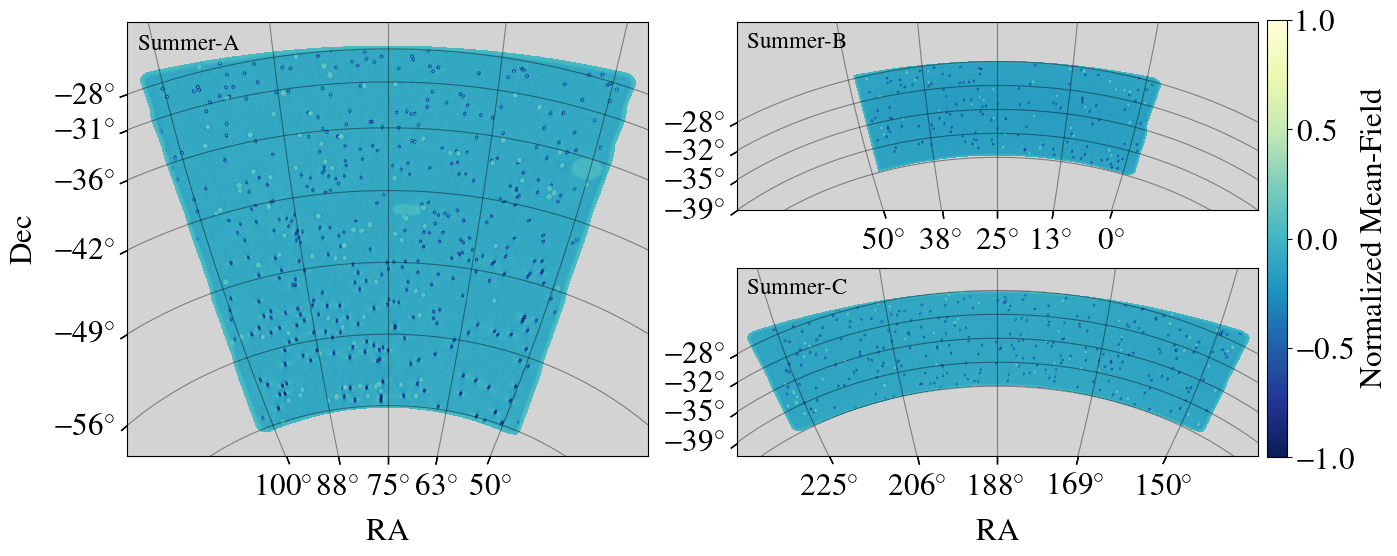

In [6]:
color_map_dic = {'summer-a':'YlGnBu_r', 'summer-b':'YlGnBu_r', 'summer-c':'YlGnBu_r'}
vborder_arr = [[-1, 1], [-1, 1], [-1, 1]]
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
label_arr = ['', '', 'Normalized Mean-Field']
axis_label_arr = [[' RA', 'Dec'], [' ', ' '], ['RA', ' ']] 
plotsize=labelsize+5.5

cmap = plt.cm.YlGnBu_r
cmap.set_bad(color='lightgrey')

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.04], height_ratios=[1, 1], wspace=0.25, hspace=-0.45) 

for i, field in enumerate(field_arr):

    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
    if i ==0:
        ax = fig.add_subplot(gs[:, 0], projection=w)
        ax.text(40, 1700, title_dic[field], color='black', fontsize=legendsize+1.5, fontweight='bold', ha='left', va='top')  
        im0 = ax.imshow(map_arr[i], cmap = color_map_dic[field], vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    if i ==1:
        ax = fig.add_subplot(gs[0, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='black', fontsize=legendsize+1.5, fontweight='bold', ha='left', va='top') 
    if i ==2:
        ax = fig.add_subplot(gs[1, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='black', fontsize=legendsize+1.5, fontweight='bold', ha='left', va='top') 

    im = ax.imshow(map_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    ax.set_xlabel(axis_label_arr[i][0], fontsize = plotsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = plotsize)
    
    ax.tick_params(direction='out', axis='x', length=6, width=1, which = 'major', top = False, bottom = True, labelsize = plotsize)
    ax.tick_params(direction='out', axis='y', length=6, width=1, which = 'major', left = True,right = False, labelsize = plotsize)
    ax.grid(color='black', ls='solid',alpha=0.4)
    
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')


cax = fig.add_subplot(gs[:, 2])  

pos = cax.get_position()

cax.set_position([
    pos.x0-0.05,           
    pos.y0+0.1425,    
    pos.width,        
    pos.height*0.631])

cb = fig.colorbar(im0, cax=cax)   
cb.set_label(label=label_arr[-1], fontsize = plotsize)
cb.ax.tick_params(labelsize=plotsize) 

plt.savefig(figures_dir+'mean_field.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

## Lensing Map (Sim)

In [7]:
nbr_pix_dic = {"summer-a":[3100, 1750], "summer-b":[3100, 1750], "summer-c":[3100, 1750]}

kmap_in_dic = {}
for field in field_arr:
    map_path = baseline_dic[field]+'kappa_in/kmap_in_seed1_smoothed1deg.fits' 
    kmap_in = hp.read_map(map_path)
    kmap_in_dic[field] = hp.gnomview(kmap_in*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)

kmap_rec_dic = {}
for field in field_arr:
    kmap_rec = hp.read_map(baseline_dic[field]+'kmaps/kmapxx_TT_1_smoothed1deg.fits')
    kmap_rec_dic[field] = hp.gnomview(kmap_rec*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)

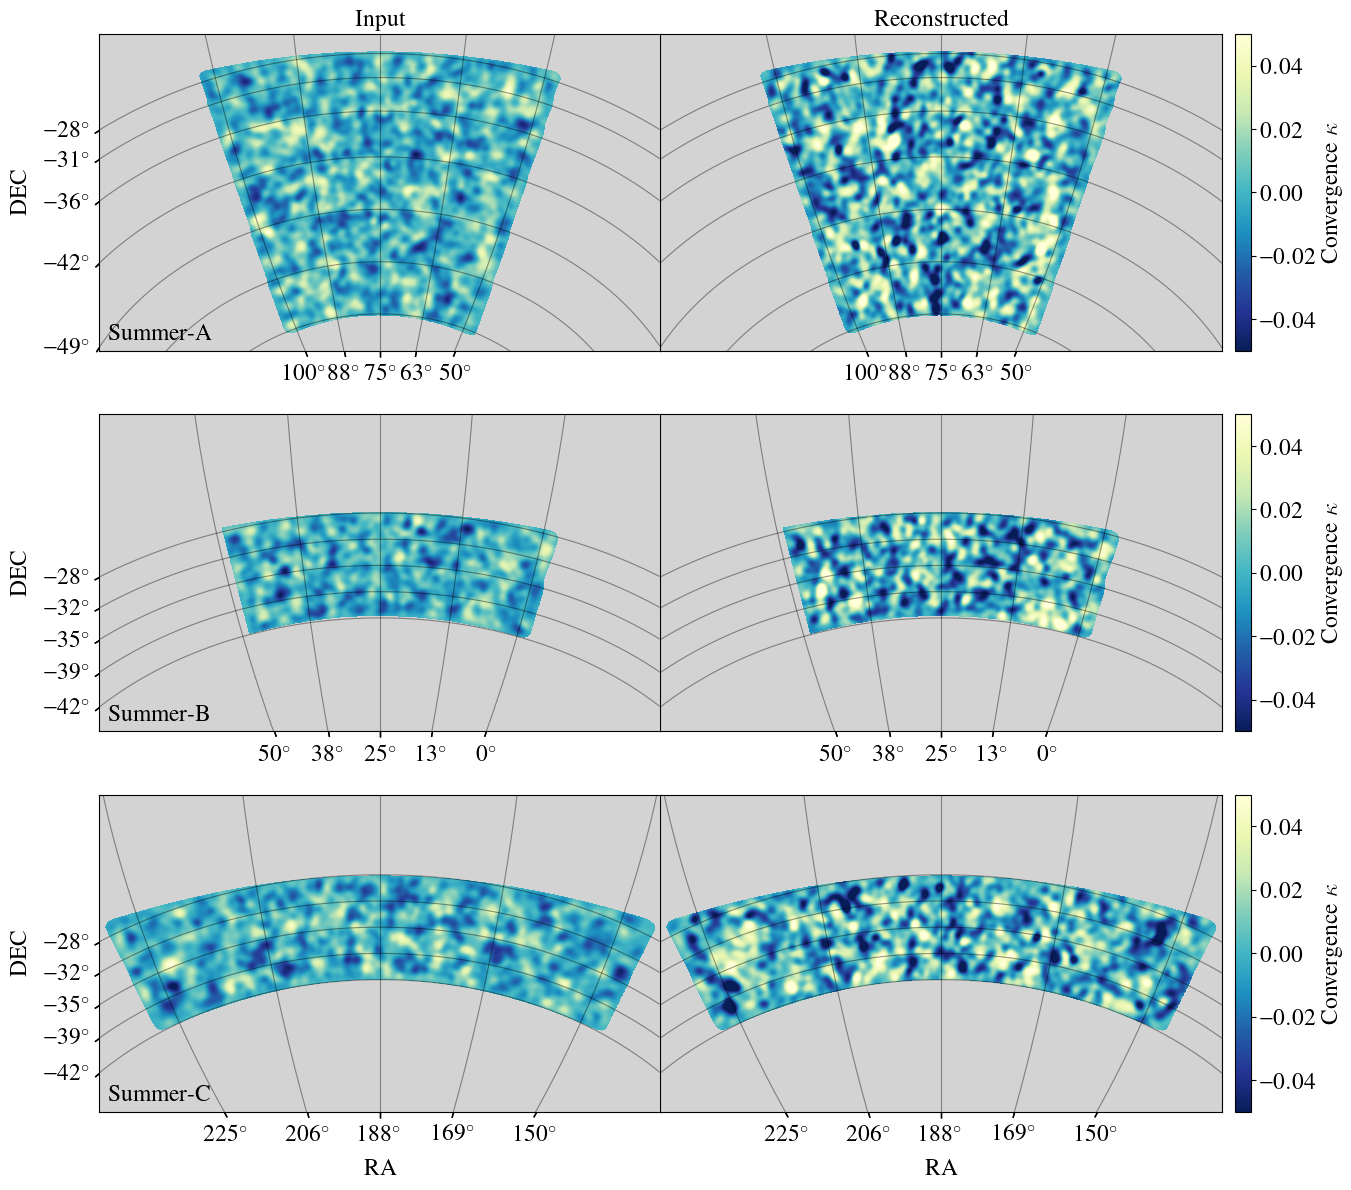

In [8]:
vborder_arr = [-0.05, 0.05]
title_arr = ['Input', 'Reconstructed']
label_arr = ['Convergence ' + r'$\kappa$', 'Convergence ' + r'$\kappa$', 'Convergence ' + r'$\kappa$']
axis_label_arr = [[' ', 'DEC'], [' ', 'DEC'], ['RA', 'DEC'], [' ', ' '], [' ', ' '], ['RA', ' ']] 
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}

fig = plt.figure(figsize=(20,14))
gs  = gridspec.GridSpec(nrows = 3, ncols = 2, figure=fig, wspace=-.795)

cmap = plt.cm.YlGnBu_r
cmap.set_bad(color='lightgrey')


for i, field in enumerate(field_arr):
    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
        
    ax = fig.add_subplot(gs[i, 0], projection=w)
    im = ax.imshow(kmap_in_dic[field], cmap=cmap, vmin=vborder_arr[0],  vmax=vborder_arr[1], origin='lower')
    if i == 0: 
        ax.set_title(title_arr[0], fontsize = labelsize)
    ax.text(50, 150, title_dic[field], color='black', fontsize=labelsize, fontweight='bold', ha='left', va='top')  

    ax.set_xlabel(axis_label_arr[i][0], fontsize = labelsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = labelsize)

    ax.grid(color='black', ls='solid',alpha=0.4)
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')
    ax.tick_params(direction='out', axis='x', length=4, width=1, which = 'major', top = False, bottom = True, labelsize = labelsize)
    ax.tick_params(direction='out', axis='y', length=4, width=1, which = 'major', left = True,right = False, labelsize = labelsize)


for i, field in enumerate(field_arr):
    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
        
    ax = fig.add_subplot(gs[i, 1], projection=w)
    im = ax.imshow(kmap_rec_dic[field], cmap=cmap, vmin=vborder_arr[0],  vmax=vborder_arr[1], origin='lower')
    if i == 0: 
        ax.set_title(title_arr[1], fontsize = labelsize)

    ax.set_xlabel(axis_label_arr[i][0], fontsize = labelsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = labelsize)
    
    ax.grid(color='black', ls='solid',alpha=0.4)
    cb = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.01, fraction=0.0405)
    cb.set_label(label=label_arr[i], fontsize = labelsize)
    cb.ax.tick_params(labelsize=labelsize) 
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')
    ax.tick_params(direction='out', axis='x', length=4, width=1, which = 'major', top = False, bottom = True, labelsize = labelsize)
    ax.tick_params(direction='out', axis='y', length=4, width=1, which = 'major', left = False, right = False, labelsize = labelsize, labelleft=False)

plt.savefig(figures_dir+'input_vs_sim.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

In [9]:
nbr_pix_dic = {"summer-a":[2100, 1850], "summer-b":[3100, 1750], "summer-c":[3100, 1750]}

kmap_in_dic = {}
for field in field_arr:
    map_path = baseline_dic[field]+'kappa_in/kmap_in_seed1_smoothed1deg.fits' 
    kmap_in = hp.read_map(map_path)
    kmap_in_dic[field] = hp.gnomview(kmap_in*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)

kmap_rec_dic = {}
for field in field_arr:
    kmap_rec = hp.read_map(baseline_dic[field]+'kmaps/kmapxx_TT_1_smoothed1deg.fits')
    kmap_rec_dic[field] = hp.gnomview(kmap_rec*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)

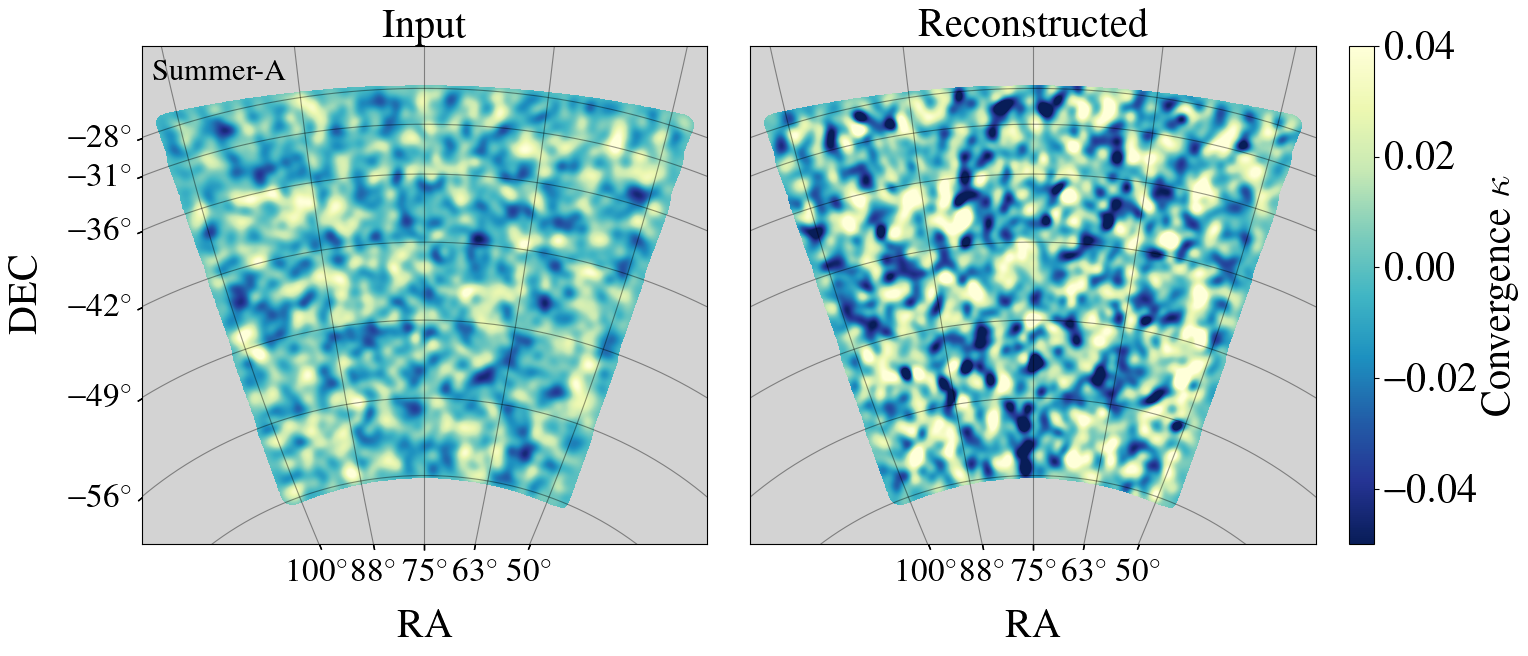

In [10]:
vborder_arr = [-0.05, 0.04]
title_arr = ['Input', 'Reconstructed']
label_arr = ['Convergence ' + r'$\kappa$', 'Convergence ' + r'$\kappa$', 'Convergence ' + r'$\kappa$']
axis_label_arr = [[' RA', 'DEC'], [' ', 'DEC'], ['RA', 'DEC'], [' ', ' '], [' ', ' '], ['RA', ' ']] 

fig = plt.figure(figsize=(35,22))
gs  = gridspec.GridSpec(nrows = 3, ncols = 2, figure=fig, wspace=-1.18)

cmap = plt.cm.YlGnBu_r
cmap.set_bad(color='lightgrey')
add_size = 12

for i, field in enumerate(['summer-a']):
    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
        
    ax = fig.add_subplot(gs[i, 0], projection=w)
    im = ax.imshow(kmap_in_dic[field], cmap=cmap, vmin=vborder_arr[0],  vmax=vborder_arr[1], origin='lower')
    if i == 0: 
        ax.set_title(title_arr[0], fontsize = labelsize+add_size)
    ax.text(40, 1800, title_dic[field], color='black', fontsize=legendsize+add_size-5, fontweight='bold', ha='left', va='top')  

    ax.set_xlabel(axis_label_arr[i][0], fontsize = labelsize+add_size)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = labelsize+add_size)

    ax.grid(color='black', ls='solid',alpha=0.4)
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')
    ax.tick_params(direction='out', axis='x', length=4, width=1, which = 'major', top = False, bottom = True, labelsize = labelsize+add_size-5)
    ax.tick_params(direction='out', axis='y', length=4, width=1, which = 'major', left = True,right = False, labelsize = labelsize+add_size-5)


for i, field in enumerate(['summer-a']):
    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
        
    ax = fig.add_subplot(gs[i, 1], projection=w)
    im = ax.imshow(kmap_rec_dic[field], cmap=cmap, vmin=vborder_arr[0],  vmax=vborder_arr[1], origin='lower')
    if i == 0: 
        ax.set_title(title_arr[1], fontsize = labelsize+add_size)

    ax.set_xlabel(axis_label_arr[i][0], fontsize = labelsize+add_size)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = labelsize+add_size)
    
    ax.grid(color='black', ls='solid',alpha=0.4)
    cb = fig.colorbar(im, ax=ax, orientation="vertical", pad=0.01, fraction=0.0405)
    cb.set_label(label=label_arr[i], fontsize = labelsize+add_size)
    cb.ax.tick_params(labelsize=labelsize+add_size) 
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')
    ax.tick_params(direction='out', axis='x', length=4, width=1, which = 'major', top = False, bottom = True, labelsize = labelsize+add_size-5)
    ax.tick_params(direction='out', axis='y', length=4, width=1, which = 'major', left = False, right = False, labelsize = labelsize+add_size-5, labelleft=False)

plt.savefig(figures_dir+'input_vs_sim_summera.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

## Lensing Map (Data)

In [11]:
nbr_pix_dic = {"summer-a":[2100, 1750], "summer-b":[3150, 1140], "summer-c":[3150, 1140]}
data_kmap_arr = []

for field in field_arr:    
    kmap_0_smoothed = hp.read_map(baseline_dic[field]+'kmaps/kmapxx_TT_0_smoothed1deg.fits') 
    kmap_0_flatsky = hp.gnomview(kmap_0_smoothed*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)
    data_kmap_arr.append(kmap_0_flatsky)

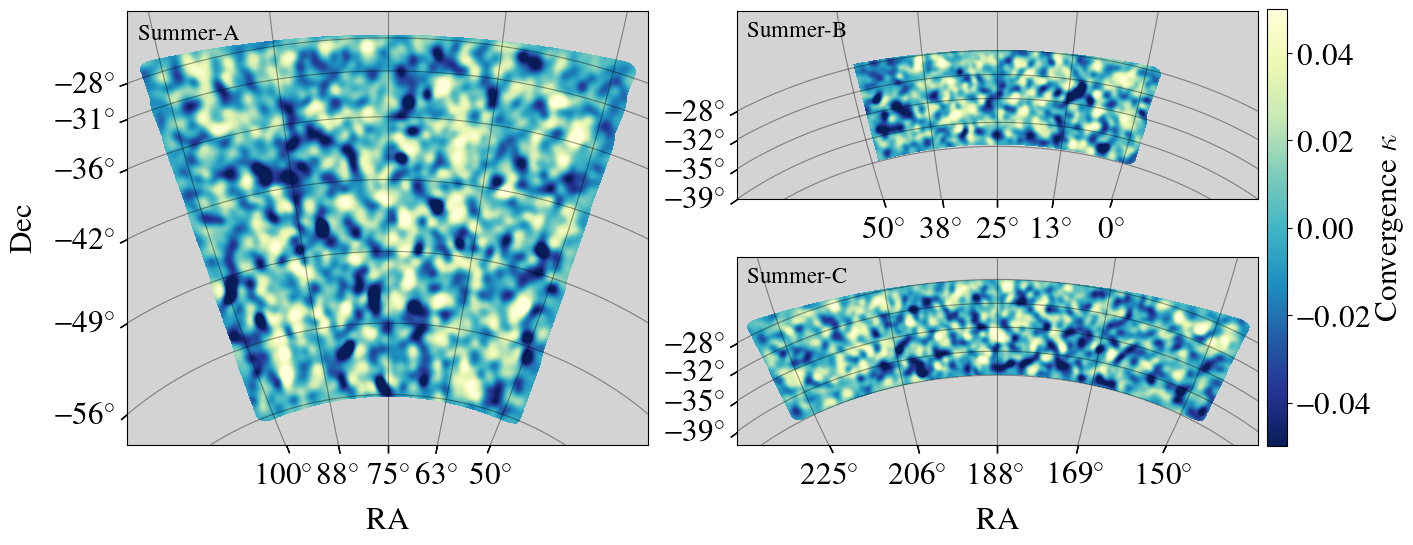

In [12]:
color_map_dic = {'summer-a':'YlGnBu_r', 'summer-b':'YlGnBu_r', 'summer-c':'YlGnBu_r'}
vborder_arr = [[-0.05, 0.05], [-0.05, 0.05], [-0.05, 0.05]]
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
label_arr = ['', '', 'Convergence ' + r'$\kappa$']
axis_label_arr = [[' RA', 'Dec'], [' ', ' '], ['RA', ' ']] 
plotsize=labelsize+5.5

cmap = plt.cm.YlGnBu_r
cmap.set_bad(color='lightgrey')

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.04], height_ratios=[1, 1], wspace=0.25, hspace=-0.45) 

for i, field in enumerate(field_arr):

    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
    if i ==0:
        ax = fig.add_subplot(gs[:, 0], projection=w)
        ax.text(40, 1700, title_dic[field], color='black', fontsize=legendsize+1.5, fontweight='bold', ha='left', va='top')  
        im0 = ax.imshow(data_kmap_arr[i], cmap = color_map_dic[field], vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    if i ==1:
        ax = fig.add_subplot(gs[0, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='black', fontsize=legendsize+1.5, fontweight='bold', ha='left', va='top') 
    if i ==2:
        ax = fig.add_subplot(gs[1, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='black', fontsize=legendsize+1.5, fontweight='bold', ha='left', va='top') 

    im = ax.imshow(data_kmap_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    ax.set_xlabel(axis_label_arr[i][0], fontsize = plotsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = plotsize)
    
    ax.tick_params(direction='out', axis='x', length=6, width=1, which = 'major', top = False, bottom = True, labelsize = plotsize)
    ax.tick_params(direction='out', axis='y', length=6, width=1, which = 'major', left = True,right = False, labelsize = plotsize)
    ax.grid(color='black', ls='solid',alpha=0.4)
    
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')


cax = fig.add_subplot(gs[:, 2])  

pos = cax.get_position()

cax.set_position([
    pos.x0-0.05,           
    pos.y0+0.1425,    
    pos.width,        
    pos.height*0.631])

cb = fig.colorbar(im0, cax=cax)   
cb.set_label(label=label_arr[-1], fontsize = plotsize)
cb.ax.tick_params(labelsize=plotsize) 

plt.savefig(figures_dir+'lensing_maps.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

In [13]:
nbr_pix_dic = {"summer-a":[2100, 1750], "summer-b":[2100, 1000], "summer-c":[3150, 1250]}
data_kmap_arr = []

field_arr=['summer-a', 'summer-b', 'summer-c']
for field in field_arr:
    kmap_0_smoothed = hp.read_map(baseline_dic[field]+'kmaps/kmapxx_TT_0_smoothed1deg.fits') 
    kmap_0_flatsky = hp.gnomview(kmap_0_smoothed*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)
    data_kmap_arr.append(kmap_0_flatsky)

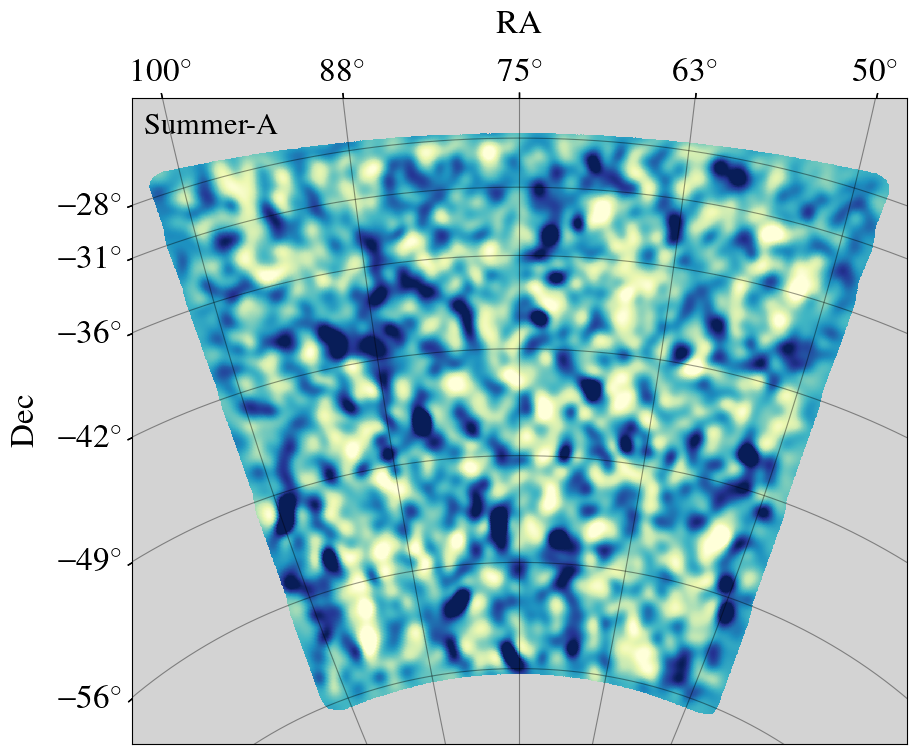

In [14]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

i=0
field_arr = ['summer-a']

# Fixed figure dimensions: same width for all, taller for 3 stacked plots
fig = plt.figure(figsize=(10, 12))  
gs = gridspec.GridSpec(len(field_arr), 1, hspace=0.3)  # equal spacing

for field in field_arr:
    # ---- Create WCS header ----
    hdr = fits.Header()
    hdr.set('NAXIS', 2)
    hdr.set('NAXIS1', nbr_pix_dic[field][0])
    hdr.set('NAXIS2', nbr_pix_dic[field][1])
    hdr.set('CTYPE1', 'RA---ZEA')
    hdr.set('CRPIX1', nbr_pix_dic[field][0] / 2)
    hdr.set('CRVAL1', cntr_dic[field][0])
    hdr.set('CDELT1', -reso_arcmin * 0.0166667)
    hdr.set('CUNIT1', 'deg')
    hdr.set('CTYPE2', 'DEC--ZEA')
    hdr.set('CRPIX2', nbr_pix_dic[field][1] / 2)
    hdr.set('CRVAL2', cntr_dic[field][1])
    hdr.set('CDELT2', reso_arcmin * 0.0166667)
    hdr.set('CUNIT2', 'deg')
    hdr.set('COORDSYS', 'icrs')

    w = WCS(hdr)

    # ---- Create subplot ----
    ax = fig.add_subplot(gs[0, 0], projection=w, aspect='equal')

    # ---- Plot map ----
    im = ax.imshow(
        data_kmap_arr[i],
        cmap=cmap,
        vmin=vborder_arr[i][0],
        vmax=vborder_arr[i][1],
        origin=origin_arr[i],
        interpolation='none')

    # ---- Title ----
    ax.text(35, 1710, title_dic[field], color='black', fontsize=legendsize+7, fontweight='bold', ha='left', va='top') 

    # ---- Move x-axis ticks and label to top ----
    ax.tick_params(
        direction='out',
        axis='x',
        length=4,
        width=1,
        which='major',
        top=True,
        bottom=False,  # disable bottom ticks
        labeltop=True,  # enable top tick labels
        labelbottom=False,
        labelsize=labelsize+7
    )
    
    ax.xaxis.set_label_position('top')  # move label to top
    ax.set_xlabel(axis_label_arr[0][0], fontsize=labelsize+7)
    
    # ---- Y-axis ticks ----
    ax.tick_params(
        direction='out',
        axis='y',
        length=4,
        width=1,
        which='major',
        left=True,
        right=False,
        labelsize=labelsize+7
    )
    ax.set_ylabel(axis_label_arr[0][1], fontsize=labelsize+7)

    ax.grid(color='black', ls='solid', alpha=0.4)

    # ---- Coordinate formatting ----
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('t')
    lon.set_axislabel_position('t')   # move RA label to top
    lat.set_axislabel_position('l')   # keep DEC label on left
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')
  

plt.savefig(figures_dir+'lensing_map_summera.pdf', dpi=250, bbox_inches='tight', pad_inches=0.1)

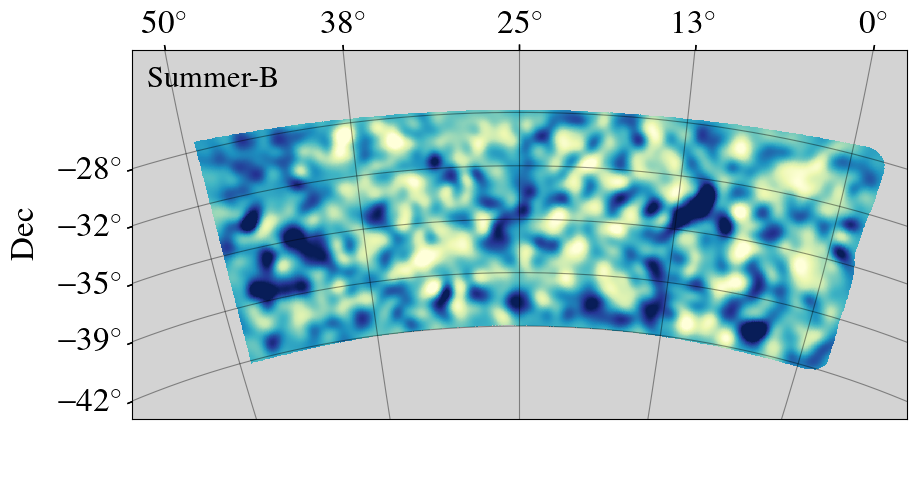

In [15]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

i=1
field_arr = ['summer-b']

# Fixed figure dimensions: same width for all, taller for 3 stacked plots
fig = plt.figure(figsize=(10, 12))  
gs = gridspec.GridSpec(len(field_arr), 1, hspace=0.3)  # equal spacing

for field in field_arr:
    # ---- Create WCS header ----
    hdr = fits.Header()
    hdr.set('NAXIS', 2)
    hdr.set('NAXIS1', nbr_pix_dic[field][0])
    hdr.set('NAXIS2', nbr_pix_dic[field][1])
    hdr.set('CTYPE1', 'RA---ZEA')
    hdr.set('CRPIX1', nbr_pix_dic[field][0] / 2)
    hdr.set('CRVAL1', cntr_dic[field][0])
    hdr.set('CDELT1', -reso_arcmin * 0.0166667)
    hdr.set('CUNIT1', 'deg')
    hdr.set('CTYPE2', 'DEC--ZEA')
    hdr.set('CRPIX2', nbr_pix_dic[field][1] / 2)
    hdr.set('CRVAL2', cntr_dic[field][1])
    hdr.set('CDELT2', reso_arcmin * 0.0166667)
    hdr.set('CUNIT2', 'deg')
    hdr.set('COORDSYS', 'icrs')

    w = WCS(hdr)

    # ---- Create subplot ----
    ax = fig.add_subplot(gs[0, 0], projection=w, aspect='equal')

    # ---- Plot map ----
    im = ax.imshow(
        data_kmap_arr[i],
        cmap=cmap,
        vmin=vborder_arr[i][0],
        vmax=vborder_arr[i][1],
        origin=origin_arr[i],
        interpolation='none')

    # ---- Title ----
    ax.text(45, 955, title_dic[field], color='black', fontsize=legendsize+7, fontweight='bold', ha='left', va='top') 

    # ---- Move x-axis ticks and label to top ----
    ax.tick_params(
        direction='out',
        axis='x',
        length=4,
        width=1,
        which='major',
        top=True,
        bottom=False,  # disable bottom ticks
        labeltop=True,  # enable top tick labels
        labelbottom=False,
        labelsize=labelsize+7
    )
    ax.xaxis.set_label_position('top')  # move label to top
    ax.set_xlabel(axis_label_arr[1][1], fontsize=labelsize+10)

    # ---- Y-axis ticks ----
    ax.tick_params(
        direction='out',
        axis='y',
        length=4,
        width=1,
        which='major',
        left=True,
        right=False,
        labelsize=labelsize+7
    )
    ax.set_ylabel(axis_label_arr[0][1], fontsize=labelsize+7)

    ax.grid(color='black', ls='solid', alpha=0.4)

    # ---- Coordinate formatting ----
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('t')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')

plt.savefig(figures_dir+'lensing_map_summerb.pdf', dpi=250, bbox_inches='tight', pad_inches=0.1)

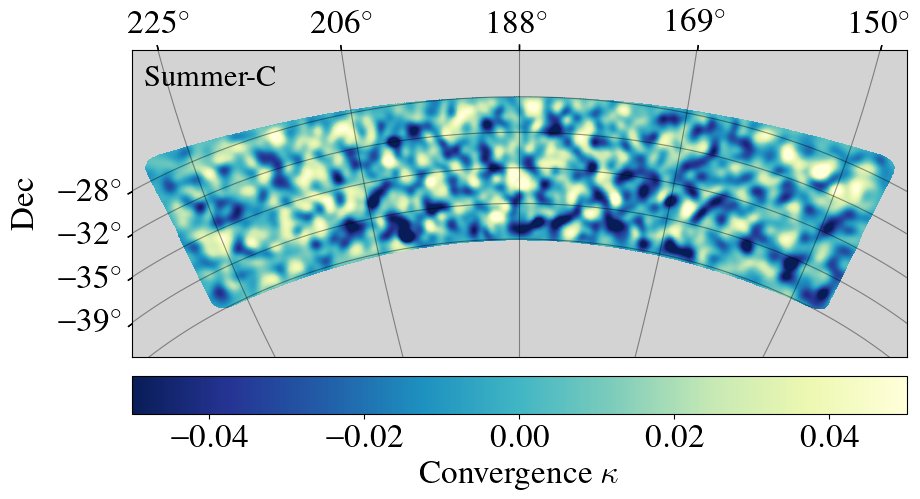

In [16]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

i=2
field_arr = ['summer-c']

fig = plt.figure(figsize=(10, 12))  
gs = gridspec.GridSpec(len(field_arr), 1, hspace=0.3)  # equal spacing

for field in field_arr:
    # ---- Create WCS header ----
    hdr = fits.Header()
    hdr.set('NAXIS', 2)
    hdr.set('NAXIS1', nbr_pix_dic[field][0])
    hdr.set('NAXIS2', nbr_pix_dic[field][1])
    hdr.set('CTYPE1', 'RA---ZEA')
    hdr.set('CRPIX1', nbr_pix_dic[field][0] / 2)
    hdr.set('CRVAL1', cntr_dic[field][0])
    hdr.set('CDELT1', -reso_arcmin * 0.0166667)
    hdr.set('CUNIT1', 'deg')
    hdr.set('CTYPE2', 'DEC--ZEA')
    hdr.set('CRPIX2', nbr_pix_dic[field][1] / 2)
    hdr.set('CRVAL2', cntr_dic[field][1])
    hdr.set('CDELT2', reso_arcmin * 0.0166667)
    hdr.set('CUNIT2', 'deg')
    hdr.set('COORDSYS', 'icrs')

    w = WCS(hdr)

    # ---- Create subplot ----
    ax = fig.add_subplot(gs[0, 0], projection=w, aspect='equal')

    # ---- Plot map ----
    im = ax.imshow(
        data_kmap_arr[i],
        cmap=cmap,
        vmin=vborder_arr[i][0],
        vmax=vborder_arr[i][1],
        origin=origin_arr[i],
        interpolation='none')

    # ---- Title ----
    ax.text(55, 1190, title_dic[field], color='black', fontsize=legendsize+7, fontweight='bold', ha='left', va='top') 

    # ---- Move x-axis ticks and label to top ----
    ax.tick_params(
        direction='out',
        axis='x',
        length=4,
        width=1,
        which='major',
        top=True,
        bottom=False,  # disable bottom ticks
        labeltop=True,  # enable top tick labels
        labelbottom=False,
        labelsize=labelsize+7
    )
    ax.xaxis.set_label_position('top')  # move label to top
    ax.set_xlabel(axis_label_arr[1][1], fontsize=labelsize+10)

    # ---- Y-axis ticks ----
    ax.tick_params(
        direction='out',
        axis='y',
        length=4,
        width=1,
        which='major',
        left=True,
        right=False,
        labelsize=labelsize+7
    )
    ax.set_ylabel(axis_label_arr[0][1], fontsize=labelsize+7)

    ax.grid(color='black', ls='solid', alpha=0.4)

    # ---- Coordinate formatting ----
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('t')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')

    # ---- Individual colorbar (horizontal above each plot) ----
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.02)
    cbar.set_label(label='Convergence ' + r'$\kappa$', fontsize=labelsize+7)
    cbar.ax.tick_params(labelsize=labelsize+7)
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.xaxis.set_ticks_position('bottom')

plt.savefig(figures_dir+'lensing_map_summerc.pdf', dpi=250, bbox_inches='tight', pad_inches=0.1)
field_arr = ['summer-a','summer-b','summer-c']

## Lensing Spectra

### Mean of Sims

In [17]:
clkk1_dic = {}
fkk_dic = {}
N0_dic = {}
RDN0_dic = {}
N1_dic = {}
clkk_mf_norm_avg_dic = {}
fMC_dic = {}

for field in field_arr:    
    clkk1_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_1a_1a_1a_1a.npz')['cls'].T[1][:Lmax]
    fkk_dic[field] =  np.load(baseline_dic[field]+'spectra/healpy/fkk_avg.npy')[:Lmax]
    N0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/N0_avg.npy')[:Lmax]
    RDN0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/RDN0_avg.npy')[:Lmax]
    N1_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/N1_avg.npy')[:Lmax]
    clkk_mf_norm_avg_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_mf_mf_mf_mf.npz')['cls'].T[1][:Lmax]
    fMC_dic[field] = clkk_theory/(fkk_dic[field]-N0_dic[field]-N1_dic[field])

# binned lensing spectra
ell0_dic = {}
cl0_dic = {}

ell1_dic = {}
cl1_dic = {}

for field in field_arr: 
    ell1_dic[field], cl1_dic[field], _ =logrebincl(ell, clkk1_dic[field]-RDN0_dic[field]-N1_dic[field], Nbins, minell, maxell)  
  
cov_dic = {}
cl_err_dic = {}
for field in field_arr:
    cl_arr = []
    for i in range(1, nsims+1):
        clkk = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]-RDN0_dic[field]-N1_dic[field]
        _,cl, _ =logrebincl(np.arange(len(clkk)), clkk, Nbins, minell, maxell) 
        cl_arr.append(cl) 
    cov = np.cov(np.asarray(cl_arr).T)
    cov_dic[field] = np.cov(np.asarray(cl_arr).T)
    cl_err_dic[field] = np.sqrt(np.diag(cov))


# amplitudes
amp_err_dic = {}
for field in field_arr:
    amp_arr = []
    for i in range(1, nsims+1):
        clkk = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]-RDN0_dic[field]-N1_dic[field]
        _,num, _ =logrebincl(np.arange(len(clkk)), clkk, Nbins, minell, maxell)
        amp_arr.append(num/clkkb_theory) 
    cov = np.cov(np.asarray(amp_arr).T)
    amp_err_dic[field] = np.sqrt(np.diag(cov))

In [18]:
fac = 1/np.sqrt(nsims)

# binnded lensing spectra
ell_dic = {}
cl_avg_dic = {}
cl_err_avg_dic = {}

for field in field_arr:
    ell_dic[field], cl_avg_dic[field], _ =logrebincl(ell, (fkk_dic[field]-N0_dic[field]-N1_dic[field]), Nbins, minell, maxell)  
    cl_err_avg_dic[field] = cl_err_dic[field]*fac

cl_avg_comb = np.zeros(Nbins)
cl_err_avg_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([cl_avg_dic['summer-a'][i],cl_avg_dic['summer-b'][i]*0.9,cl_avg_dic['summer-c'][i]])
    sig=np.asarray([cl_err_avg_dic['summer-a'][i],cl_err_avg_dic['summer-b'][i],cl_err_avg_dic['summer-c'][i]])
    cl_avg_comb[i] = np.sum(sig**(-2)*spec)/np.sum(sig**(-2))
    cl_err_avg_comb[i] = (1/np.sum(sig**-2))**0.5


# amplitudes
ell_dic = {}
amp_avg_dic = {}
amp_err_avg_dic = {}

for field in field_arr:
    ell_dic[field], amp_avg_dic[field], _ =logrebincl(ell, (fkk_dic[field]-N0_dic[field]-N1_dic[field]), Nbins, minell, maxell) 
    amp_avg_dic[field] /= clkkb_theory
    amp_err_avg_dic[field] = amp_err_dic[field]*fac
    
amp_avg_comb = np.zeros(Nbins)
amp_err_avg_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([amp_avg_dic['summer-a'][i],amp_avg_dic['summer-b'][i]*0.9,amp_avg_dic['summer-c'][i]])
    sig=np.asarray([amp_err_avg_dic['summer-a'][i],amp_err_avg_dic['summer-b'][i],amp_err_avg_dic['summer-c'][i]])
    amp_avg_comb[i] = np.sum(sig**(-2)*spec)/np.sum(sig**(-2))
    amp_err_avg_comb[i] = (1/np.sum(sig**-2))**0.5

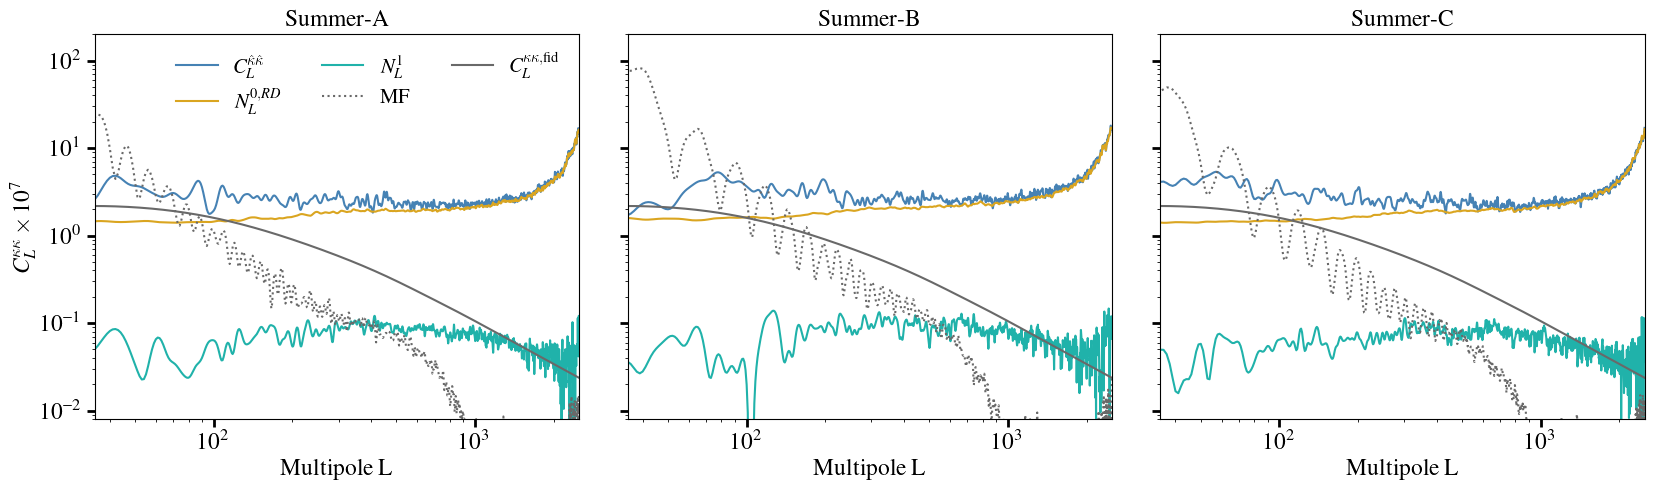

In [19]:
fig, ax_arr = plt.subplots(1, len(field_arr), sharey=True, figsize=(20,5))
plt.subplots_adjust(hspace=0.2, wspace = 0.1)

for cntr, field in enumerate(field_arr):
    ax_arr[cntr].plot(np.arange(len(clkk1_dic[field])), (clkk1_dic[field])*1e7, color=color_arr[0] , label=r'$C_{L}^{\hat{\kappa}\hat{\kappa}}$')
    ax_arr[cntr].plot(np.arange(len(N0_dic[field])), N0_dic[field]*1e7, color=color_arr[1], label=r'$N_L^{0, RD}$')
    ax_arr[cntr].plot(np.arange(len(N1_dic[field])), N1_dic[field]*1e7, color=color_arr[2], label=r'$N_L^{1}$')
    ax_arr[cntr].plot(np.arange(len(clkk_mf_norm_avg_dic[field])), clkk_mf_norm_avg_dic[field]*1e7, label = 'MF', ls =':', color = color_arr[-1])
    ax_arr[cntr].plot(np.arange(len(clkk_theory)), clkk_theory*1e7, label = r'$C_{L}^{\kappa\kappa, \rm fid}$', color = color_arr[-1])

    ax_arr[cntr].set_xscale('log')
    ax_arr[cntr].set_yscale('log')
    ax_arr[cntr].set_xlim(3.5e1, 2.5e3)
    ax_arr[cntr].set_xlabel(r'Multipole L', fontsize=labelsize)
    
    ax_arr[cntr].set_title(title_dic[field], fontsize=labelsize) 
    ax_arr[cntr].tick_params(labelsize = labelsize, length = 6, width = 2)

    if cntr==0:
        ax_arr[cntr].set_ylim(8e-3, 2e2)
        ax_arr[cntr].set_ylabel(r'$C_L^{\kappa\kappa} \times 10^7$', fontsize=labelsize)
        ax_arr[cntr].legend(fontsize=legendsize, ncol=3, frameon=False)

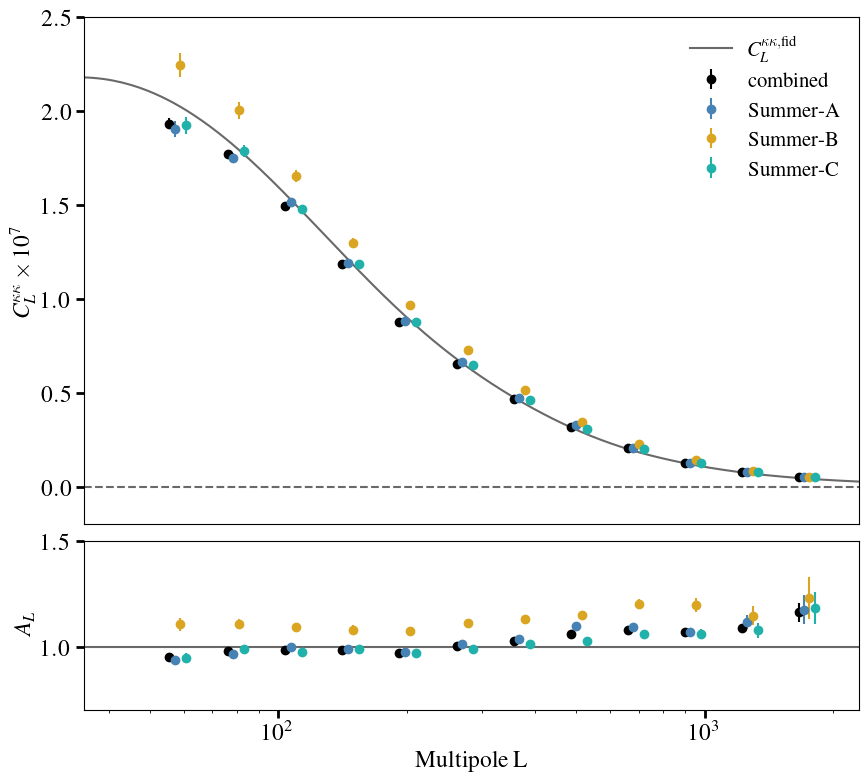

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols=1, nrows=2, figsize = (10,9), constrained_layout=True, gridspec_kw={'height_ratios':[3,1]}) 
plt.subplots_adjust(hspace=0.05)

ax1.errorbar(ell_dic[field]/(log_offset**1.5), cl_avg_comb*1e7, yerr=cl_err_avg_comb*1e7, marker = 'o', ls='None', color=color_arr[3], label=r'$\rm combined$')

for i, field in enumerate(field_arr):
    if field == 'summer-a':
        ax1.errorbar(ell_dic[field]/(log_offset**0.5), cl_avg_dic[field]*1e7, yerr=cl_err_avg_dic[field]*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_dic[field])
    elif field == 'summer-b':
        ax1.errorbar(ell_dic[field]*(log_offset**(0.5+(i-1))), cl_avg_dic[field]*1e7, yerr=cl_err_avg_dic[field]*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_dic[field])
    else:
        ax1.errorbar(ell_dic[field]*(log_offset**(0.5+(i-1))), cl_avg_dic[field]*1e7, yerr=cl_err_avg_dic[field]*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_dic[field])


ax1.plot(ell, clkk_theory*1e7, label = r'$C_{L}^{\kappa\kappa, \rm fid}$', color = color_arr[-1])
ax1.axhline(0, ls = '--', color = color_arr[-1])
ax1.set_xscale('log')
ax1.set_ylabel(r'$ C_L^{\kappa\kappa} \times 10^7 $', fontsize=labelsize)
ax1.legend(prop={'size': legendsize}, frameon=False)
ax1.tick_params(labelsize = labelsize, length = 6, width = 2)
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) 
ax1.set_ylim(-.2, 2.5)
ax1.set_xlim(3.5e1, 2.3e3)

ax2.errorbar(ell_dic[field]/(log_offset**1.5), amp_avg_comb, yerr=amp_err_avg_comb, marker = 'o', ls='None', color=color_arr[3], label=r'$\langle \rm combined \rangle$')


for i, field in enumerate(field_arr):
    if field == 'summer-a':
        ax2.errorbar(ell_dic[field]/(log_offset**0.5), amp_avg_dic[field], yerr=amp_err_avg_dic[field], marker = 'o', ls='None', color=color_arr[i])
    elif field == 'summer-b':
        ax2.errorbar(ell_dic[field]*(log_offset**(0.5+(i-1))), amp_avg_dic[field], yerr=amp_err_avg_dic[field], marker = 'o', ls='None', color=color_arr[i])
    else:
        ax2.errorbar(ell_dic[field]*(log_offset**(0.5+(i-1))), amp_avg_dic[field], yerr=amp_err_avg_dic[field], marker = 'o', ls='None', color=color_arr[i])

ax2.axhline(1, color = color_arr[-1])
ax2.tick_params(labelsize = labelsize, length = 6, width = 2)
ax2.set_xlabel('Multipole L', fontsize=labelsize)
ax2.set_ylabel(r'$A_L$', fontsize=labelsize)
ax2.set_ylim(0.7, 1.5)
ax2.set_xlim(3.5e1, 2.3e3)
ax2.set_xscale('log')

In [21]:
diff_dic = {}
field_arr = ['summer-a', 'summer-b', 'summer-c']
for field in field_arr:
    if field=='summer-b':
        ell_dic[field], amp_avg_dic[field], _ =logrebincl(ell, (fkk_dic[field]-N0_dic[field]-N1_dic[field])-clkk_theory, Nbins, minell, maxell)  
    else:
        ell_dic[field], amp_avg_dic[field], _ =logrebincl(ell, (fkk_dic[field]-N0_dic[field]-N1_dic[field])-clkk_theory, Nbins, minell, maxell)  
    diff_dic[field]= amp_avg_dic[field]/cl_err_dic[field]   

err_diff_dic = {}
field_arr = ['summer-a', 'summer-b', 'summer-c']
for field in field_arr:
    cl_arr = []
    for i in range(1, nsims+1):
        clkk = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]-N0_dic[field]-N1_dic[field]
        if field=='summer-b':
            _, cl, _ =logrebincl(ell, clkk-clkk_theory, Nbins, minell, maxell)  
        else:
            _, cl, _ =logrebincl(ell, clkk-clkk_theory, Nbins, minell, maxell)  
        cl_arr.append(cl/cl_err_dic[field]/np.sqrt(nsims)) 
    cov = np.cov(np.asarray(cl_arr).T)
    err_diff_dic[field] = np.sqrt(np.diag(cov))

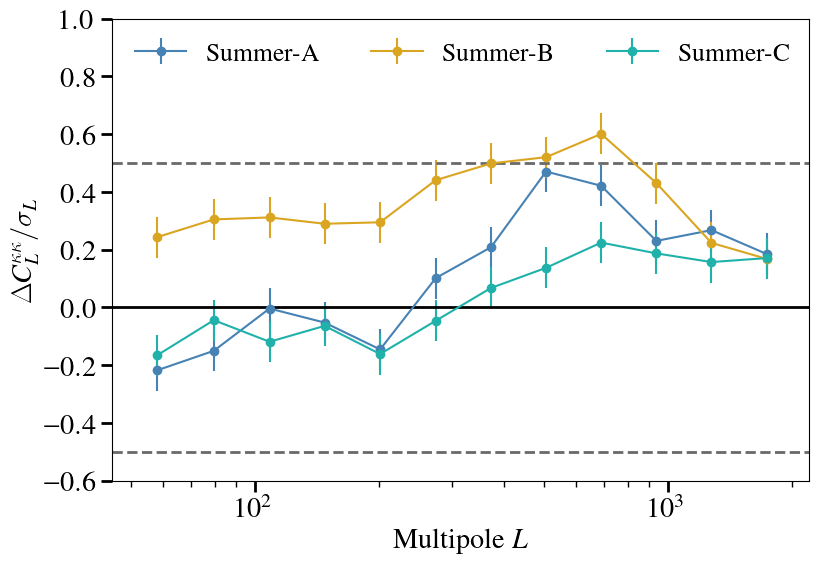

In [22]:
label_arr=['Summer-A', 'Summer-B', 'Summer-C']
fig, ax = plt.subplots(figsize = (9,6))
for i, field in enumerate(field_arr):
    if field == 'summer-a':
        plt.errorbar(ell_dic[field], diff_dic[field], yerr=err_diff_dic[field], ls ='-', marker='o', color=color_arr[i], label=label_arr[i])   
    else:
        plt.errorbar(ell_dic[field],diff_dic[field], yerr=err_diff_dic[field], ls ='-', marker='o', color=color_arr[i], label=label_arr[i])
ax.legend(fontsize=legendsize+3.5, frameon=False, ncol=3, loc = 'upper left')
ax.set_xscale('log')
ax.axhline(0, ls='-', color='k', lw=2.)
ax.axhline(-0.5, ls='--', color=color_arr[-1], lw=2.)
ax.axhline(0.5, ls='--', color=color_arr[-1], lw=2.)
ax.set_ylabel(r'$\Delta C_{L}^{\kappa\kappa}/\sigma_{L}$', fontsize=labelsize+3.5)
ax.set_xlabel('Multipole' + r' $L$', fontsize=labelsize+3.5)
ax.set_ylim(-0.6,1)
ax.set_xlim(4.5e1, 2.2e3)
ax.tick_params(which='major', labelsize = labelsize+3.5, length = 8, width = 2)
ax.tick_params(which='minor', labelsize = labelsize+3.5, length = 4, width = 1)
plt.savefig(figures_dir+'mc_bias.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

### Analysis Choices

In [23]:
import numpy as np
from scipy.stats import chi2

def fit_amp(data_vec, template_vec, cinv):
    """Return best-fit amplitude A for data_vec given template_vec and inv-cov cinv."""
    denom = template_vec @ cinv @ template_vec
    return (template_vec @ cinv @ data_vec) / denom

def amp_sigma(template_vec, cinv):
    """Return sigma(A) for template fit."""
    denom = template_vec @ cinv @ template_vec
    return 1.0 / np.sqrt(denom)

def hartlap_factor(nsims, p):
    """Hartlap correction factor for inverse covariance (optional)."""
    return (nsims - p - 2.0) / (nsims - 1.0)

def combine_sigma(sigmas):
    """
    Combine independent amplitude errors (sigmas) via inverse-variance weighting:
      sigma_comb = 1/sqrt(sum_i 1/sigma_i^2)
    """
    sigmas = np.asarray(sigmas)
    wsum = np.sum(1.0 / sigmas**2)
    return np.sqrt(1.0 / wsum)

# -------------------------------------------------
# 0) Load baseline mean spectra + compute baseline d
# -------------------------------------------------
clkk0_dic, fkk_dic, N0_dic, RDN0_dic, N1_dic, fMC_dic = {}, {}, {}, {}, {}, {}
ell0_dic, cl0_dic = {}, {}

for field in field_arr:
    clkk0_dic[field] = np.load(baseline_dic[field] + "spectra/healpy/clkk_TT_1a_1a_1a_1a.npz")['cls'].T[1][:Lmax]
    fkk_dic[field]   = np.load(baseline_dic[field] + "spectra/healpy/fkk_avg.npy")[:Lmax]
    N0_dic[field]    = np.load(baseline_dic[field] + "spectra/healpy/N0_avg.npy")[:Lmax]
    RDN0_dic[field]  = np.load(baseline_dic[field] + "spectra/healpy/RDN0_avg.npy")[:Lmax]
    N1_dic[field]    = np.load(baseline_dic[field] + "spectra/healpy/N1_avg.npy")[:Lmax]

    fMC_dic[field] = clkk_theory / (fkk_dic[field] - N0_dic[field] - N1_dic[field])

    clkk0 = (clkk0_dic[field] - RDN0_dic[field] - N1_dic[field]) * fMC_dic[field]
    ell0_dic[field], cl0_dic[field], _ = logrebincl(ell, clkk0, Nbins, minell, maxell)
    cl0_dic[field] = cl0_dic[field][:-1]  # drop last (outlier) bin

# Template vector (must match binning and length)
t = clkkb_theory[:-1]
p = len(t)  # number of bins used in fit

# ----------------------------------------
# 1) Baseline covariance from baseline sims
# ----------------------------------------
cov_dic, cinv_dic = {}, {}
A1_best_dic, sigma1_dic = {}, {}

for field in field_arr:
    cl_sims = []
    for j in range(1, nsims + 1):
        clkk = np.load(
            baseline_dic[field]
            + f"spectra/healpy/clkk_TT_{j}a_{j}a_{j}a_{j}a.npz"
        )["cls"].T[1][:Lmax]

        _, cl, _ = logrebincl(np.arange(len(clkk)),
                              (clkk - N0_dic[field] - N1_dic[field]) * fMC_dic[field],
                              Nbins, minell, maxell)
        cl_sims.append(cl[:-1])

    cov = np.cov(np.asarray(cl_sims).T, ddof=1)
    cov_dic[field] = cov

    # Invert covariance (+ optional Hartlap)
    cinv = np.linalg.inv(cov)
    # if nsims > p + 2:
    #     cinv *= hartlap_factor(nsims, p)
    cinv_dic[field] = cinv

    # Best-fit baseline amplitude from the *mean* spectrum
    A1_best_dic[field] = fit_amp(cl0_dic[field], t, cinv)
    sigma1_dic[field]  = amp_sigma(t, cinv)

# Baseline combined sigma (independent-fields approximation)
comb_fields = ["summer-a", "summer-b", "summer-c"]
sigma_base_comb = combine_sigma([sigma1_dic[f] for f in comb_fields])
snr_base_comb = 1.0 / sigma_base_comb

# ---------------------------------------------------------
# 2) Load alternative mean spectra (for each alternative case)
# ---------------------------------------------------------
cases = [lmin_alt1_dic, lmin_alt2_dic, lmax_alt1_dic, lmax_alt2_dic, mmin_alt_dic]
cases_names = ["lmin_alt1", "lmin_alt2", "lmax_alt1", "lmax_alt2", "mmin_alt"]

cl0_alt_dic = {}
N0_alt_dic, N1_alt_dic, fMC_alt_dic = {}, {}, {}

for name, case in zip(cases_names, cases):
    cl0_alt_dic[name] = {}
    N0_alt_dic[name], N1_alt_dic[name], fMC_alt_dic[name] = {}, {}, {}

    for field in field_arr:
        fkk_alt   = np.load(case[field] + "spectra/healpy/fkk_avg.npy")[:Lmax]
        N0_alt    = np.load(case[field] + "spectra/healpy/N0_avg.npy")[:Lmax]
        N1_alt    = np.load(case[field] + "spectra/healpy/N1_avg.npy")[:Lmax]
        RDN0_alt  = np.load(case[field] + "spectra/healpy/RDN0_avg.npy")[:Lmax]
        clkk0_alt = np.load(case[field] + "spectra/healpy/clkk0_avg.npy")[:Lmax]

        N0_alt_dic[name][field] = N0_alt
        N1_alt_dic[name][field] = N1_alt
        fMC_alt_dic[name][field] = clkk_theory / (fkk_alt - N0_alt - N1_alt)

        clkk0_alt_corr = (clkk0_alt - RDN0_alt - N1_alt) * fMC_alt_dic[name][field]
        _, cl_alt, _ = logrebincl(np.arange(len(clkk0_alt_corr)),
                                  clkk0_alt_corr,
                                  Nbins, minell, maxell)
        cl0_alt_dic[name][field] = cl_alt[:-1]

# -------------------------------------------------------------------
# 3) For each alternative: compute A2_best, ΔA_best, σ(ΔA), and SNR loss
# -------------------------------------------------------------------
delta_amp_dic, err_delta_amp_dic = {}, {}
A2_best_dic, sigma2_dic = {}, {}
pte_dic = {}
snr_loss_pct_dic = {}          # per field
snr_loss_pct_comb_dic = {}     # combined

for name, case in zip(cases_names, cases):
    print("\n", name)
    delta_amp_dic[name], err_delta_amp_dic[name] = {}, {}
    A2_best_dic[name], sigma2_dic[name] = {}, {}
    pte_dic[name] = {}
    snr_loss_pct_dic[name] = {}

    for field in field_arr:
        # --- Build alt covariance from alt sims ---
        cl_alt_sims = []
        for j in range(1, nsims + 1):
            clkk_alt = np.load(
                case[field]
                + f"spectra/healpy/bundle0Xbundle0/clkk_TT_{j}a_{j}a_{j}a_{j}a.npz"
            )["cls"].T[1][:Lmax]

            _, cl_alt, _ = logrebincl(np.arange(len(clkk_alt)),
                                      (clkk_alt - N0_alt_dic[name][field] - N1_alt_dic[name][field]) * fMC_alt_dic[name][field],
                                      Nbins, minell, maxell)
            cl_alt_sims.append(cl_alt[:-1])

        cov_alt = np.cov(np.asarray(cl_alt_sims).T, ddof=1)
        cinv_alt = np.linalg.inv(cov_alt)
        # if nsims > p + 2:
        #     cinv_alt *= hartlap_factor(nsims, p)

        # --- Best-fit amplitudes from mean spectra ---
        A2_best = fit_amp(cl0_alt_dic[name][field], t, cinv_alt)
        sig2    = amp_sigma(t, cinv_alt)

        A2_best_dic[name][field] = A2_best
        sigma2_dic[name][field]  = sig2

        A1_best = A1_best_dic[field]

        # NOTE: define ΔA consistently (baseline - alt) or (alt - baseline). Pick one and stick with it.
        delta_best = A2_best-A1_best 
        delta_amp_dic[name][field] = delta_best

        # --- SNR loss (statistical sensitivity) ---
        # SNR ∝ 1/sigma for a single-parameter template fit
        snr_base = 1.0 / sigma1_dic[field]
        snr_alt  = 1.0 / sig2
        snr_loss_pct = 100.0 * (1.0 - snr_alt / snr_base)  # = 100*(1 - sigma_base/sigma_alt)
        snr_loss_pct_dic[name][field] = snr_loss_pct

        # --- Monte-Carlo error on ΔA using paired sims (same j) ---
        delta_sims = []
        cinv_base = cinv_dic[field]
        denom_base = t @ cinv_base @ t
        denom_alt  = t @ cinv_alt  @ t

        for j in range(1, nsims + 1):
            # baseline sim j
            clkk = np.load(
                baseline_dic[field]
                + f"spectra/healpy/clkk_TT_{j}a_{j}a_{j}a_{j}a.npz"
            )["cls"].T[1][:Lmax]
            _, cl, _ = logrebincl(np.arange(len(clkk)),
                                  (clkk - N0_dic[field] - N1_dic[field]) * fMC_dic[field],
                                  Nbins, minell, maxell)
            cl = cl[:-1]
            A1_sim = (t @ cinv_base @ cl) / denom_base

            # alt sim j
            clkk_alt = np.load(
                case[field]
                + f"spectra/healpy/bundle0Xbundle0/clkk_TT_{j}a_{j}a_{j}a_{j}a.npz"
            )["cls"].T[1][:Lmax]
            _, cl_alt, _ = logrebincl(np.arange(len(clkk_alt)),
                                      (clkk_alt - N0_alt_dic[name][field] - N1_alt_dic[name][field]) * fMC_alt_dic[name][field],
                                      Nbins, minell, maxell)
            cl_alt = cl_alt[:-1]
            A2_sim = (t @ cinv_alt @ cl_alt) / denom_alt

            delta_sims.append(A2_sim-A1_sim)

        err_delta = np.std(delta_sims, ddof=1)
        err_delta_amp_dic[name][field] = err_delta

        # --- Significance / PTE for this field (1 dof) ---
        chi2_val = (delta_best / err_delta) ** 2
        pte = 1 - chi2.cdf(chi2_val, df=1)
        pte_dic[name][field] = pte

        print(f"Field: {field}")
        print(f"  ΔA = {delta_best:.3f}")
        print(f"  σ(ΔA) = {err_delta:.3f}")
        print(f"  chi2 (1 dof) = {chi2_val:.3f}, PTE = {pte:.2f}")
        print(f"  σA baseline = {sigma1_dic[field]:.4f}")
        print(f"  σA alt      = {sig2:.4f}")
        print(f"  SNR loss    = {snr_loss_pct:.2f}%")

    # --- Combine (example: three summer fields) ---
    spec = np.array([delta_amp_dic[name][f] for f in comb_fields])
    sig  = np.array([err_delta_amp_dic[name][f] for f in comb_fields])

    w = 1.0 / sig**2
    delta_comb = np.sum(w * spec) / np.sum(w)
    err_comb = np.sqrt(1.0 / np.sum(w))

    # PTEs
    chi2_mean = (delta_comb / err_comb) ** 2
    pte_mean = 1 - chi2.cdf(chi2_mean, df=1)

    chi2_vec = np.sum((spec / sig) ** 2)              # assumes independent fields
    pte_vec = 1 - chi2.cdf(chi2_vec, df=len(comb_fields))

    # --- Combined SNR loss (compare combined sigmas) ---
    sigma_alt_comb = combine_sigma([sigma2_dic[name][f] for f in comb_fields])
    snr_alt_comb = 1.0 / sigma_alt_comb
    snr_loss_comb_pct = 100.0 * (1.0 - snr_alt_comb / snr_base_comb)
    snr_loss_pct_comb_dic[name] = snr_loss_comb_pct

    print("Field: combined (summer-a/b/c)")
    print(f"  ΔA_comb = {delta_comb:.3f}")
    print(f"  σ(ΔA)_comb = {err_comb:.3f}")
    print(f"  chi2_mean (1 dof) = {chi2_mean:.3f}, PTE_mean = {pte_mean:.2f}")
    print(f"  chi2_vec ({len(comb_fields)} dof) = {chi2_vec:.3f}, PTE_vec = {pte_vec:.2f}")
    print(f"  σA_comb baseline = {sigma_base_comb:.4f}")
    print(f"  σA_comb alt      = {sigma_alt_comb:.4f}")
    print(f"  Combined SNR loss = {snr_loss_comb_pct:.2f}%")


 lmin_alt1
Field: summer-a
  ΔA = 0.081
  σ(ΔA) = 0.007
  chi2 (1 dof) = 123.267, PTE = 0.00
  σA baseline = 0.0806
  σA alt      = 0.0803
  SNR loss    = -0.39%
Field: summer-b
  ΔA = -0.187
  σ(ΔA) = 0.011
  chi2 (1 dof) = 282.318, PTE = 0.00
  σA baseline = 0.1153
  σA alt      = 0.1154
  SNR loss    = 0.08%
Field: summer-c
  ΔA = -0.089
  σ(ΔA) = 0.008
  chi2 (1 dof) = 131.110, PTE = 0.00
  σA baseline = 0.0937
  σA alt      = 0.0931
  SNR loss    = -0.58%
Field: combined (summer-a/b/c)
  ΔA_comb = -0.033
  σ(ΔA)_comb = 0.005
  chi2_mean (1 dof) = 48.553, PTE_mean = 0.00
  chi2_vec (3 dof) = 536.695, PTE_vec = 0.00
  σA_comb baseline = 0.0540
  σA_comb alt      = 0.0538
  Combined SNR loss = -0.35%

 lmin_alt2
Field: summer-a
  ΔA = 0.093
  σ(ΔA) = 0.013
  chi2 (1 dof) = 52.119, PTE = 0.00
  σA baseline = 0.0806
  σA alt      = 0.0811
  SNR loss    = 0.56%
Field: summer-b
  ΔA = -0.176
  σ(ΔA) = 0.016
  chi2 (1 dof) = 119.357, PTE = 0.00
  σA baseline = 0.1153
  σA alt      = 0.11

In [24]:
# -----------------------------
# 1) Baseline mean + baseline err (diag only)
# -----------------------------
cl0_dic = {}
cl_err_dic = {}

for field in field_arr:
    # mean baseline spectrum
    clkk0 = np.load(baseline_dic[field] + "spectra/healpy/clkk_TT_0a_0a_0a_0a.npz")['cls'].T[1][:Lmax]
    fkk   = np.load(baseline_dic[field] + "spectra/healpy/fkk_avg.npy")[:Lmax]
    N0    = np.load(baseline_dic[field] + "spectra/healpy/N0_avg.npy")[:Lmax]
    RDN0  = np.load(baseline_dic[field] + "spectra/healpy/RDN0_avg.npy")[:Lmax]
    N1    = np.load(baseline_dic[field] + "spectra/healpy/N1_avg.npy")[:Lmax]

    fMC = clkk_theory / (fkk - N0 - N1)
    clkk0_corr = (clkk0 - RDN0 - N1) * fMC

    _, cl0, _ = logrebincl(ell, clkk0_corr, Nbins, minell, maxell)
    cl0 = apply_lastbin_scale(field, cl0.copy())
    cl0_dic[field] = cl0

    # baseline covariance diagonal from sims
    cl_sims = []
    for j in range(1, nsims + 1):
        clkk = np.load(
            baseline_dic[field]
            + f"spectra/healpy/clkk_TT_{j}a_{j}a_{j}a_{j}a.npz"
        )["cls"].T[1][:Lmax]

        _, cl, _ = logrebincl(np.arange(len(clkk)), (clkk - N0 - N1) * fMC, Nbins, minell, maxell)
        cl = apply_lastbin_scale(field, cl.copy())
        cl_sims.append(cl)

    cl_sims = np.asarray(cl_sims)  # (nsims, Nbins)
    cl_err_dic[field] = np.std(cl_sims, axis=0, ddof=1)  # diag errors only

# -----------------------------
# 2) Alternatives: mean diagnostic curve + its scatter across paired sims
# -----------------------------
cases = [lmin_alt1_dic, lmin_alt2_dic, lmax_alt1_dic, lmax_alt2_dic, mmin_alt_dic]
cases_names = ["lmin_alt1", "lmin_alt2", "lmax_alt1", "lmax_alt2", "mmin_alt"]

delta_dic = {}
err_delta_dic = {}
cl0_alt_dic = {}

for name, case in zip(cases_names, cases):
    delta_dic[name] = {}
    err_delta_dic[name] = {}
    cl0_alt_dic[name] = {}

    for field in field_arr:
        # alt mean spectrum
        clkk0_alt = np.load(case[field] + "spectra/healpy/clkk0_avg.npy")[:Lmax]
        fkk_alt   = np.load(case[field] + "spectra/healpy/fkk_avg.npy")[:Lmax]
        N0_alt    = np.load(case[field] + "spectra/healpy/N0_avg.npy")[:Lmax]
        RDN0_alt  = np.load(case[field] + "spectra/healpy/RDN0_avg.npy")[:Lmax]
        N1_alt    = np.load(case[field] + "spectra/healpy/N1_avg.npy")[:Lmax]

        fMC_alt = clkk_theory / (fkk_alt - N0_alt - N1_alt)
        clkk0_alt_corr = (clkk0_alt - RDN0_alt - N1_alt) * fMC_alt

        _, cl_alt0, _ = logrebincl(np.arange(len(clkk0_alt_corr)), clkk0_alt_corr, Nbins, minell, maxell)
        cl_alt0 = apply_lastbin_scale(field, cl_alt0.copy())
        cl0_alt_dic[name][field] = cl_alt0

        # mean diagnostic curve (your requested quantity)
        delta_dic[name][field] = (cl_alt0 - cl0_dic[field])/clkkb_theory #(cl0_dic[field] - cl_alt0) / cl_err_dic[field]

        # scatter of diagnostic curve across paired sims
        delta_norm_sims = []
        for j in range(1, nsims + 1):
            # baseline sim j
            clkk = np.load(
                baseline_dic[field]
                + f"spectra/healpy/clkk_TT_{j}a_{j}a_{j}a_{j}a.npz"
            )["cls"].T[1][:Lmax]
            _, cl, _ = logrebincl(np.arange(len(clkk)), (clkk - N0 - N1) * fMC, Nbins, minell, maxell)
            cl = apply_lastbin_scale(field, cl.copy())

            # alt sim j
            clkk_a = np.load(
                case[field]
                + f"spectra/healpy/bundle0Xbundle0/clkk_TT_{j}a_{j}a_{j}a_{j}a.npz"
            )["cls"].T[1][:Lmax]
            _, cl_a, _ = logrebincl(np.arange(len(clkk_a)), (clkk_a - N0_alt - N1_alt) * fMC_alt, Nbins, minell, maxell)
            cl_a = apply_lastbin_scale(field, cl_a.copy())

            delta_norm_sims.append((cl_a-cl)/clkkb_theory) #((cl - cl_a) / cl_err_dic[field])

        delta_norm_sims = np.asarray(delta_norm_sims)  # (nsims, Nbins)
        err_delta_dic[name][field] = np.std(delta_norm_sims, axis=0, ddof=1)

# -----------------------------
# 3) Combine summer a/b/c per bin (diagnostic units)
# -----------------------------
delta_comb_dic = {}
err_delta_comb_dic = {}

comb_fields = ["summer-a", "summer-b", "summer-c"]

for name in cases_names:
    delta_comb = np.zeros(Nbins)
    err_comb = np.zeros(Nbins)

    for k in range(Nbins):
        spec = np.array([delta_dic[name][f][k] for f in comb_fields])
        sig  = np.array([err_delta_dic[name][f][k] for f in comb_fields])

        w = 1.0 / sig**2
        delta_comb[k] = np.sum(w * spec) / np.sum(w)
        err_comb[k]   = np.sqrt(1.0 / np.sum(w))

    delta_comb_dic[name] = delta_comb
    err_delta_comb_dic[name] = err_comb

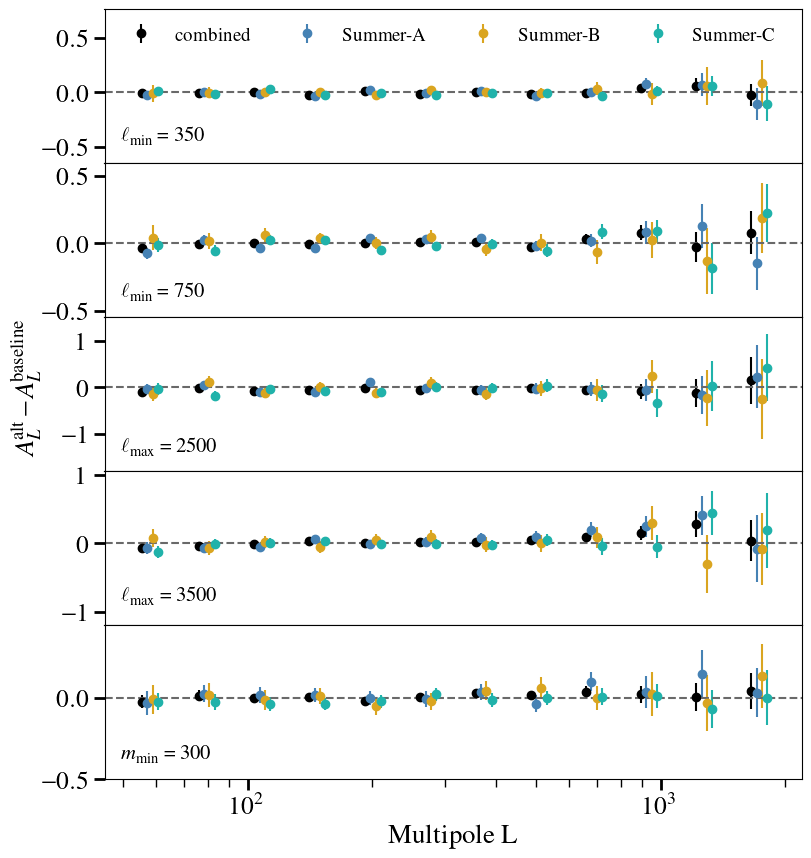

In [25]:
title_arr = ['Summer-A', 'Summer-B', 'Summer-C']
delta_comb_arr = [delta_comb_dic[name] for name in cases_names]
err_delta_comb_arr = [err_delta_comb_dic[name] for name in cases_names]

fig, ax_arr = plt.subplots(ncols=1, nrows=5, figsize = (9,10), constrained_layout=True) 
plt.subplots_adjust(hspace=0.00)
fig.supylabel(r'$A_{L}^{\rm alt} - A_{L}^{\rm baseline}$', fontsize=labelsize+2.5)  #(r'$\Delta C_{L}^{\kappa\kappa}/\sigma_{L}^{\rm baseline}$', fontsize=labelsize+2)

for j in range(len(ax_arr)):
    ax_arr[j].errorbar(ell0_dic[field]/ (log_offset**1.5), delta_comb_arr[j], yerr=err_delta_comb_arr[j], marker = 'o', ls='None', color=color_arr[3], label=r'combined')

    for i, field in enumerate(field_arr):
        if field == 'summer-a':
            ax_arr[j].errorbar(ell0_dic[field]/ (log_offset**0.5), delta_dic[cases_names[j]][field], yerr=err_delta_dic[cases_names[j]][field], marker = 'o', ls='None', color=color_arr[i], label=title_arr[i])
        else:
            ax_arr[j].errorbar(ell0_dic[field]* (log_offset**(0.5+(i-1))), delta_dic[cases_names[j]][field], yerr=err_delta_dic[cases_names[j]][field], marker = 'o', ls='None', color=color_arr[i], label=title_arr[i])

    ax_arr[j].axhline(0, ls = '--', color = color_arr[-1])
    ax_arr[j].set_xscale('log')
    ax_arr[j].set_xlim(4.5e1, 2.2e3)
    ax_arr[j].tick_params(which='major', labelsize = labelsize+1.5, length = 8, width = 2)
    ax_arr[j].tick_params(which='minor', labelsize = labelsize+1.5, length = 6, width = 1)
    
    if j == 0:
        ax_arr[j].legend(loc='upper left', ncol=4, frameon=False, fontsize=legendsize-1.25)
        ax_arr[j].text(49.2, -0.45, r"$\ell_{\rm min} = 350$", fontsize=legendsize, color="black")
        ax_arr[j].set_ylim(-.65, .76)
    if j == 1:
        ax_arr[j].text(49.2, -0.4, r"$\ell_{\rm min} = 750$", fontsize=legendsize, color="black")
        ax_arr[j].set_ylim(-.55, .59)
    if j == 2:
        ax_arr[j].text(49.2, -1.38, r"$\ell_{\rm max} = 2500$", fontsize=legendsize, color="black")
        ax_arr[j].set_ylim(-1.8, 1.5)
    if j == 3:
        ax_arr[j].text(49.2, -0.85, r"$\ell_{\rm max} = 3500$", fontsize=legendsize, color="black")
        ax_arr[j].set_ylim(-1.2, 1.05)
    if j == 4:
        ax_arr[j].set_xlabel('Multipole L', fontsize=labelsize+2.5)
        ax_arr[j].text(49.2, -0.38, r"$m_{\rm min} = 300$", fontsize=legendsize, color="black")
        ax_arr[j].set_ylim(-.50, .44)
        
plt.savefig(figures_dir+'systematic_tests.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

### Null Tests

In [26]:
clkk0_dic = {}
clkk1_dic = {}
fkk_dic = {}
N0_dic = {}
RDN0_dic = {}
N1_dic = {}
clkk_mf_norm_avg_dic = {}
fMC_dic = {} 

for field in field_arr:    
    clkk0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_0a_0a_0a_0a.npz')['cls'].T[1][:Lmax]
    fkk_dic[field] =  np.load(baseline_dic[field]+'spectra/healpy/fkk_avg.npy')[:Lmax]
    N0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/N0_avg.npy')[:Lmax]
    RDN0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/RDN0_avg.npy')[:Lmax]
    N1_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/N1_avg.npy')[:Lmax]
    clkk_mf_norm_avg_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_mf_mf_mf_mf.npz')['cls'].T[1][:Lmax]
    fMC_dic[field] = clkk_theory/(fkk_dic[field]-N0_dic[field]-N1_dic[field])

# binned lensing spectra
ell0_dic = {}
cl0_dic = {}

for field in field_arr:
    ell0_dic[field], cl0_dic[field], _ =logrebincl(ell, (clkk0_dic[field]-RDN0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell) 

cl_err_dic = {}
cov_dic = {}
A_best_arr = []
for field in field_arr:
    print("Field: ", field)
    cl_arr = []
    weights_arr = []
    for i in range(1, nsims+1):
        clkk = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]
        bins,cl, _ =logrebincl(np.arange(len(clkk)), (clkk-N0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell) 

        cl_arr.append(cl) 
    cov = np.cov(np.asarray(cl_arr).T)
    cov_dic[field] = cov
    corr = np.corrcoef(np.asarray(cl_arr).T)

    cl_err_dic[field] = np.sqrt(np.diag(cov))

    # Best-fit amplitude
    cinv = np.linalg.inv(cov)
    A_best = clkkb_theory @ cinv @ cl0_dic[field] / (clkkb_theory @ cinv @ clkkb_theory)
    A_best_arr.append(A_best)
    A_err  = 1.0 / np.sqrt(clkkb_theory @ cinv @ clkkb_theory)
    print("A_best: ", A_best, A_err)
    residual = cl0_dic[field] - A_best * clkkb_theory
    chi2_val = residual @ cinv @ residual
    dof = len(cl0_dic[field]) - 1
    print("Chi2/dof =", chi2_val/dof)
    pte = 1 - chi2.cdf(chi2_val, dof)
    print("PTE =", pte)

    print("SNR: ", cl0_dic[field]/cl_err_dic[field])


cl0_comb = np.zeros(Nbins)
cl_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([cl0_dic['summer-a'][i],cl0_dic['summer-b'][i],cl0_dic['summer-c'][i]])
    sig=np.asarray([cl_err_dic['summer-a'][i],cl_err_dic['summer-b'][i],cl_err_dic['summer-c'][i]])
    cl0_comb[i] = np.sum(sig**(-2)*spec)/np.sum(sig**(-2))
    cl_err_comb[i] = (1/np.sum(sig**-2))**0.5

print("Field: ", 'combined')
A_best_comb, A_err_comb = combine_lensing_amplitude(cl0_dic, clkkb_theory, err_dic=None, cov_dic=cov_dic)
print("A_best = ", A_best_comb, A_err_comb)
chi2_tot, dof, pte = chi2_pte_combined(cl0_dic, clkkb_theory, cov_dic, A_best_comb)
print("Chi2/dof =", chi2_tot/dof)
print("PTE =", pte)

# amplitudes
ell0_dic = {}
amp0_dic = {}
delta_dic = {}
for field in field_arr:
    ell0_dic[field], cl0b, _ =logrebincl(ell, (clkk0_dic[field]-RDN0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell)  
    amp0_dic[field] = cl0b/clkkb_theory
    
amp_err_dic = {}
for field in field_arr:
    amp_arr = []
    for i in range(1, nsims+1):
        clkk = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]
        _,clkkb, _ =logrebincl(np.arange(len(clkk)), (clkk-N0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell) 
        amp_arr.append(clkkb/clkkb_theory) 

    cov = np.cov(np.asarray(amp_arr).T)
    amp_err_dic[field] = np.sqrt(np.diag(cov))

amp0_comb = np.zeros(Nbins)
amp_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([amp0_dic['summer-a'][i], amp0_dic['summer-b'][i], amp0_dic['summer-c'][i]])
    sig = np.array([amp_err_dic['summer-a'][i],amp_err_dic['summer-b'][i],amp_err_dic['summer-c'][i]])
    weights = 1.0 / sig**2
    amp0_comb[i] = np.sum(weights * spec) / np.sum(weights)
    amp_err_comb[i] = np.sqrt(1.0 / np.sum(weights))


print('Unlensed')
# unlensed
clunl1_dic = {}
funl_dic = {}
N0unl_dic = {}


for field in field_arr:    
    clunl1_dic[field] = np.load(unlensed_dic[field]+'spectra/healpy/clkk1_avg.npy')[:Lmax]
    funl_dic[field] =  np.load(unlensed_dic[field]+'spectra/healpy/fkk_avg.npy')[:Lmax]
    N0unl_dic[field] = np.load(unlensed_dic[field]+'spectra/healpy/N0_avg.npy')[:Lmax]

ell1_dic = {}
clu1_dic = {}

for field in field_arr:
    ell1_dic[field], clu1_dic[field], _ =logrebincl(ell, (clunl1_dic[field]-N0unl_dic[field])*fMC_dic[field], Nbins, minell, maxell)  

clu_err_dic = {}
cov_dic = {} 
cov_arr = []
for field in field_arr:
    print("Field: ", field)
    cl_arr = []
    for i in range(2, nsims_unlensed+1):
        clunl = np.load(unlensed_dic[field]+'spectra/healpy/bundle%sXbundle%s/clkk_TT_%sa_%sa_%sa_%sa.npz'%(0,0,i,i,i,i))['cls'].T[1][:Lmax]
        _,cl, _ =logrebincl(np.arange(len(clunl)), (clunl-N0unl_dic[field])*fMC_dic[field], Nbins, minell, maxell) 

        cl_arr.append(cl) 
    cov = np.cov(np.asarray(cl_arr).T)
    cov_dic[field] = cov
    cov_arr.append(cov)
    clu_err_dic[field] = np.sqrt(np.diag(cov))  #/np.sqrt(nsims_unlensed)

    # Best-fit amplitude
    cinv = np.linalg.inv(cov)
    model = clkkb_theory
    A_best = model @ cinv @ clu1_dic[field] / (model @ cinv @ model)
    A_err  = 1.0 / np.sqrt(model @ cinv @ model)
    print("A_best: ", A_best, A_err)
    residual = clu1_dic[field] - A_best * model
    chi2_val = residual @ cinv @ residual
    dof = len(clu1_dic[field]) - 1
    print("Chi2/dof =", chi2_val/dof)
    pte = 1 - chi2.cdf(chi2_val, dof)
    print("PTE =", pte)

clu1_comb = np.zeros(Nbins)
clu_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([clu1_dic['summer-a'][i],clu1_dic['summer-b'][i],clu1_dic['summer-c'][i]])
    sig=np.asarray([clu_err_dic['summer-a'][i],clu_err_dic['summer-b'][i],clu_err_dic['summer-c'][i]])
    clu1_comb[i] = np.sum(sig**(-2)*spec)/np.sum(sig**(-2))
    clu_err_comb[i] = (1/np.sum(sig**-2))**0.5

print("Field: ", 'combined')
Au_best_comb, Au_err_comb = combine_lensing_amplitude(clu1_dic, clkkb_theory, err_dic=None, cov_dic=cov_dic)
print("A_best = ", Au_best_comb, Au_err_comb)
chi2_tot, dof, pte = chi2_pte_combined(clu1_dic, clkkb_theory, cov_dic, Au_best_comb)
print("Chi2/dof =", chi2_tot/dof)
print("PTE =", pte)


def fit_amplitude(C_data, C_theory, cov):
    """Fit amplitude A for one spectrum given covariance."""
    inv_cov = np.linalg.inv(cov)
    num = C_theory @ inv_cov @ C_data
    den = C_theory @ inv_cov @ C_theory
    return num / den

def combine_amplitudes(A_list, sigma_list):
    """Inverse-variance combine amplitudes and compute combined sigma."""
    inv_var = 1.0 / np.square(sigma_list)
    A_comb = np.sum(A_list * inv_var) / np.sum(inv_var)
    sigma_comb = np.sqrt(1.0 / np.sum(inv_var))
    return A_comb, sigma_comb

n_sims = 149
n_spec = 3

# 2. Estimate sigma(A_i) from unlensed sims
A_sims = np.zeros((n_sims, n_spec))

sims_spectra = np.zeros((n_sims, n_spec, Nbins))
for i, field in enumerate(field_arr):
    for j in range(1, nsims_unlensed+1):
        clunl = np.load(unlensed_dic[field]+'spectra/healpy/bundle%sXbundle%s/clkk_TT_%sa_%sa_%sa_%sa.npz'%(0,0,j,j,j,j))['cls'].T[1][:Lmax]
        _,cl, _ =logrebincl(np.arange(len(clunl)), (clunl-N0unl_dic[field])*fMC_dic[field], Nbins, minell, maxell) 
        sims_spectra[j, i, :] = cl 

for i in range(n_spec):    
    A_sims[:, i] = [fit_amplitude(sims_spectra[j, i], clkkb_theory, cov_arr[i]) for j in range(n_sims)]
sigma_A = np.std(A_sims, axis=0, ddof=1)

# 3. Combine amplitudes for data
A_comb_data, sigma_comb_data = combine_amplitudes(A_best_arr, sigma_A)

# 4. Combine amplitudes for each unlensed sim
A_comb_sims = np.zeros(n_sims)
for j in range(n_sims):
    A_comb_sims[j], _ = combine_amplitudes(A_sims[j], sigma_A)

# 5. Compute null variance and detection significance
sigma_null = np.std(A_comb_sims, ddof=1)
significance = 1.014677000766849 / sigma_null #A_comb_data / sigma_null
print(f"Detection significance: {significance:.1f} σ")


# amplitudes
ellu1_dic = {}
ampu1_dic = {}
for field in field_arr:
    ellu1_dic[field], cl1ub, _ =logrebincl(ell, (clunl1_dic[field]-N0unl_dic[field])*fMC_dic[field], Nbins, minell, maxell)  
    ampu1_dic[field] = cl1ub/clkkb_theory
    
ampu_err_dic = {}
for field in field_arr:
    amp_arr = []
    for i in range(2, nsims_unlensed+1):
        clkk = np.load(unlensed_dic[field]+'spectra/healpy/bundle%sXbundle%s/clkk_TT_%sa_%sa_%sa_%sa.npz'%(0,0,i,i,i,i))['cls'].T[1][:Lmax]
        _,clkkb, _ =logrebincl(np.arange(len(clkk)), (clkk-N0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell)
        amp_arr.append(clkkb/clkkb_theory) 

    cov = np.cov(np.asarray(amp_arr).T)
    ampu_err_dic[field] = np.sqrt(np.diag(cov))

ampu1_comb = np.zeros(Nbins)
ampu_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([ampu1_dic['summer-a'][i], ampu1_dic['summer-b'][i], ampu1_dic['summer-c'][i]])
    sig = np.array([ampu_err_dic['summer-a'][i],ampu_err_dic['summer-b'][i],ampu_err_dic['summer-c'][i]])
    weights = 1.0 / sig**2
    ampu1_comb[i] = np.sum(weights * spec) / np.sum(weights)
    ampu_err_comb[i] = np.sqrt(1.0 / np.sum(weights))


print('')
print('L-R')
# L-R
cl_lr0_dic = {}
flr_dic = {}
N0lr_dic = {}
RDN0lr_dic = {}

for field in field_arr:    
    cl_lr0_dic[field] = np.load(leftright_dic[field]+'spectra/healpy/clkk0_avg.npy')[:Lmax]
    N0lr_dic[field] = np.load(leftright_dic[field]+'spectra/healpy/N0_avg.npy')[:Lmax]
    RDN0lr_dic[field] = np.load(leftright_dic[field]+'spectra/healpy/RDN0_avg.npy')[:Lmax]


ell_lr_dic = {}
cllr0_dic = {}

for field in field_arr:
    ell_lr_dic[field], cllr0_dic[field], _ =logrebincl(ell, (cl_lr0_dic[field]-RDN0lr_dic[field]), Nbins, minell, maxell)  

cl_err_lr_dic = {}
cov_dic = {} 
for field in field_arr:
    print("Field: ", field)
    cl_arr = []
    for i in range(1, nsims_unlensed+1):
        cl = np.load(leftright_dic[field]+'spectra/healpy/bundle%sXbundle%s/clkk_TT_%sa_%sa_%sa_%sa.npz'%(0,0,i,i,i,i))['cls'].T[1][:Lmax]
        _,cl, _ =logrebincl(np.arange(len(cl)), (cl-RDN0lr_dic[field]), Nbins, minell, maxell)         
        cl_arr.append(cl) 
    cov = np.cov(np.asarray(cl_arr).T)
    cov_dic[field] = cov
    cl_err_lr_dic[field] = np.sqrt(np.diag(cov))

    # Best-fit amplitude
    cinv = np.linalg.inv(cov)
    A_best = clkkb_theory @ cinv @ cllr0_dic[field] / (clkkb_theory @ cinv @ clkkb_theory)
    A_err  = 1.0 / np.sqrt(clkkb_theory @ cinv @ clkkb_theory)
    print("A_best: ", A_best, A_err)
    residual = cllr0_dic[field] - A_best * clkkb_theory
    chi2_val = residual @ cinv @ residual
    dof = len(cl0_dic[field]) - 1
    print("Chi2/dof =", chi2_val/dof)
    pte = 1 - chi2.cdf(chi2_val, dof)
    print("PTE =", pte)


cl_lr_comb = np.zeros(Nbins)
cl_lr_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([cllr0_dic['summer-a'][i],cllr0_dic['summer-b'][i],cllr0_dic['summer-c'][i]])
    sig=np.asarray([cl_err_lr_dic['summer-a'][i],cl_err_lr_dic['summer-b'][i],cl_err_lr_dic['summer-c'][i]])
    cl_lr_comb[i] = np.sum(sig**(-2)*spec)/np.sum(sig**(-2))
    cl_lr_err_comb[i] = (1/np.sum(sig**-2))**0.5


print("Field: ", 'combined')
Alr_best_comb, Alr_err_comb = combine_lensing_amplitude(cllr0_dic, clkkb_theory, err_dic=None, cov_dic=cov_dic)
print("A_best = ", Alr_best_comb, Alr_err_comb)
chi2_tot, dof, pte = chi2_pte_combined(cllr0_dic, clkkb_theory, cov_dic, Alr_best_comb)
print("Chi2/dof =", chi2_tot/dof)
print("PTE =", pte)


# amplitudes
elllr0_dic = {}
amplr0_dic = {}
for field in field_arr:
    elllr0_dic[field], cllr0b, _ =logrebincl(ell, (cl_lr0_dic[field]-N0lr_dic[field])*fMC_dic[field], Nbins, minell, maxell)  
    amplr0_dic[field] = cllr0b/clkkb_theory
    
amplr_err_dic = {}
for field in field_arr:
    amp_arr = []
    for i in range(2, nsims_unlensed+1):
        clkk = np.load(leftright_dic[field]+'spectra/healpy/bundle%sXbundle%s/clkk_TT_%sa_%sa_%sa_%sa.npz'%(0,0,i,i,i,i))['cls'].T[1][:Lmax]
        _,clkkb, _ =logrebincl(np.arange(len(clkk)), (clkk-N0lr_dic[field])*fMC_dic[field], Nbins, minell, maxell)
        amp_arr.append(clkkb/clkkb_theory) 

    cov = np.cov(np.asarray(amp_arr).T)
    amplr_err_dic[field] = np.sqrt(np.diag(cov))

amplr0_comb = np.zeros(Nbins)
amplr_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([amplr0_dic['summer-a'][i], amplr0_dic['summer-b'][i], amplr0_dic['summer-c'][i]])
    sig = np.array([amplr_err_dic['summer-a'][i],amplr_err_dic['summer-b'][i],amplr_err_dic['summer-c'][i]])
    weights = 1.0 / sig**2
    amplr0_comb[i] = np.sum(weights * spec) / np.sum(weights)
    amplr_err_comb[i] = np.sqrt(1.0 / np.sum(weights))


print('')
print('Curl')
# curl
baseline_dic = {}
for field in field_arr:
    baseline_dir = '/sptlocal/user/kevinlevy/summerfield_lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/' %(field)
    baseline_dic[field] = baseline_dir
    
clww0_dic = {}
clww1_dic = {}
fww_dic = {}
N0ww_dic = {}
RDN0ww_dic = {}
N1ww_dic = {}

for field in field_arr:    
    clww0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/clww_TT_0a_0a_0a_0a.npz')['cls'].T[1][:Lmax]
    fww_dic[field] =  np.load(baseline_dic[field]+'spectra/healpy/fww_avg.npy')[:Lmax]
    N0ww_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/N0ww_avg.npy')[:Lmax]
    RDN0ww_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/RDN0ww_avg.npy')[:Lmax]
    N1ww_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/N1ww_avg.npy')[:Lmax]


ell0_dic = {}
clw0_dic = {}
for field in field_arr:
    ell0_dic[field], clw0_dic[field], _ =logrebincl(ell, (clww0_dic[field]-RDN0ww_dic[field]-N1ww_dic[field])*fMC_dic[field], Nbins, minell, maxell)  
    
clw_err_dic = {}
cov_dic = {} 
for field in field_arr:
    print("Field: ", field)
    cl_arr = []
    for i in range(1, nsims+1):
        clww = np.load(baseline_dic[field]+'spectra/healpy/clww_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]
        _,cl, _ =logrebincl(np.arange(len(clww)), (clww-N0ww_dic[field]-N1ww_dic[field]), Nbins, minell, maxell) 
        
        cl_arr.append(cl) 
    cov = np.cov(np.asarray(cl_arr).T)
    cov_dic[field] = cov
    clw_err_dic[field] = np.sqrt(np.diag(cov))

    # Best-fit amplitude
    cinv = np.linalg.inv(cov)
    model = clkkb_theory
    A_best = model @ cinv @ clw0_dic[field] / (model @ cinv @ model)
    A_err  = 1.0 / np.sqrt(model @ cinv @ model)
    print("A_best: ", A_best, A_err)
    residual = clw0_dic[field] - A_best * model
    chi2_val = residual @ cinv @ residual
    dof = len(clw0_dic[field]) - 1
    print("Chi2/dof =", chi2_val/dof)
    pte = 1 - chi2.cdf(chi2_val, dof)
    print("PTE =", pte)

clw0_comb = np.zeros(Nbins)
clw_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([clw0_dic['summer-a'][i],clw0_dic['summer-b'][i],clw0_dic['summer-c'][i]])
    sig=np.asarray([clw_err_dic['summer-a'][i],clw_err_dic['summer-b'][i],clw_err_dic['summer-c'][i]])
    clw0_comb[i] = np.sum(sig**(-2)*spec)/np.sum(sig**(-2))
    clw_err_comb[i] = (1/np.sum(sig**-2))**0.5

print("Field: ", 'combined')
Aw_best_comb, Aw_err_comb = combine_lensing_amplitude(clw0_dic, clkkb_theory, err_dic=None, cov_dic=cov_dic)
print("A_best = ", Aw_best_comb, Aw_err_comb)
chi2_tot, dof, pte = chi2_pte_combined(clw0_dic, clkkb_theory, cov_dic, Aw_best_comb)
print("Chi2/dof =", chi2_tot/dof)
print("PTE =", pte)

# amplitudes
ellw0_dic = {}
ampw0_dic = {}
for field in field_arr:
    ellw0_dic[field], clw0b, _ =logrebincl(ell, (clww0_dic[field]-RDN0ww_dic[field]-N1ww_dic[field])*fMC_dic[field], Nbins, minell, maxell)  

    ampw0_dic[field] = clw0b/clkkb_theory
    
ampw_err_dic = {}
for field in field_arr:
    amp_arr = []
    for i in range(1, nsims+1):
        clkk = np.load(baseline_dic[field]+'spectra/healpy/clww_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]
        _,clkkb, _ =logrebincl(np.arange(len(clkk)), (clkk-RDN0ww_dic[field]-N1ww_dic[field])*fMC_dic[field], Nbins, minell, maxell)
              
        amp_arr.append(clkkb/clkkb_theory) 

    cov = np.cov(np.asarray(amp_arr).T)
    ampw_err_dic[field] = np.sqrt(np.diag(cov))

ampw0_comb = np.zeros(Nbins)
ampw0_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([ampw0_dic['summer-a'][i], ampw0_dic['summer-b'][i], ampw0_dic['summer-c'][i]])
    sig = np.array([ampw_err_dic['summer-a'][i],ampw_err_dic['summer-b'][i],ampw_err_dic['summer-c'][i]])
    weights = 1.0 / sig**2
    ampw0_comb[i] = np.sum(weights * spec) / np.sum(weights)
    ampw0_err_comb[i] = np.sqrt(1.0 / np.sum(weights))

Field:  summer-a
A_best:  1.006640425704836 0.07791058884757418
Chi2/dof = 0.8521401749014704
PTE = 0.5874546208013932
SNR:  [3.37090425 3.23056095 5.50348493 5.50612419 6.32747854 7.08010345
 6.34021417 4.57848475 5.68949506 2.34087758 1.07734907 1.05629887]
Field:  summer-b
A_best:  0.8795302123048604 0.11490568657207778
Chi2/dof = 1.0426434944414416
PTE = 0.4048421066934772
SNR:  [ 2.07782581  2.17073419  2.47297182  3.44992071  3.96585699  3.58090287
  4.46182963  5.62003968  2.42632199  1.56515452  2.29213726 -0.96811957]
Field:  summer-c
A_best:  1.073183834884461 0.09297394151177742
Chi2/dof = 0.4773000734627807
PTE = 0.9184410824493479
SNR:  [3.33462783 4.37272764 6.36903854 4.98615017 4.86170988 5.62399499
 4.41097497 4.90872953 3.91495591 4.16330634 1.39631697 0.96914785]
Field:  combined
A_best =  1.0012242536559999 0.05298749031327047
Chi2/dof = 0.7948125100427685
PTE = 0.8006790674243928
Unlensed
Field:  summer-a
A_best:  0.003086009254818971 0.04157292608208395
Chi2/dof =

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


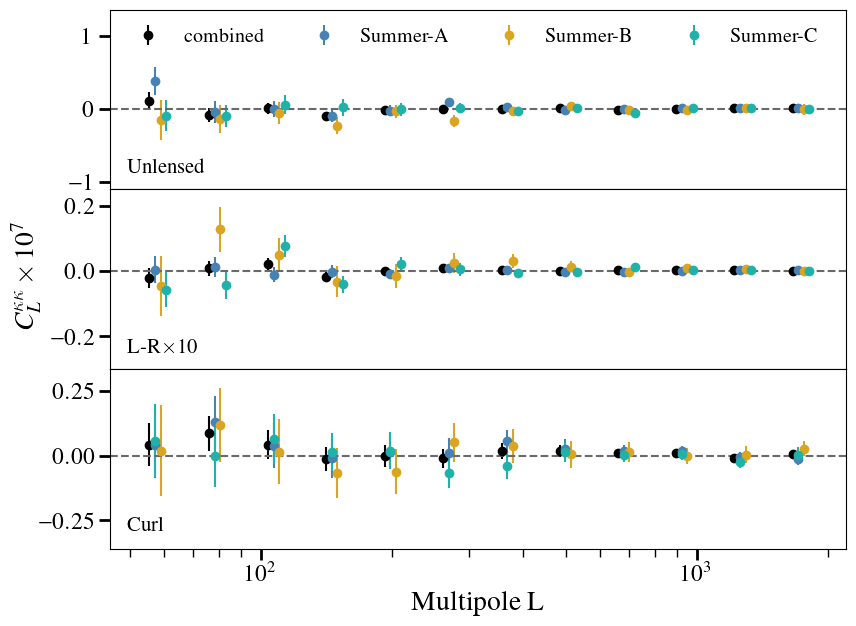

In [27]:
title_arr = ['Summer-A', 'Summer-B', 'Summer-C']
fig, (ax1, ax2, ax3) = plt.subplots(ncols=1, nrows=3, figsize = (9.5,7), constrained_layout=True) 
plt.subplots_adjust(hspace=0.00)

fig.supylabel(r'$  C_L^{\kappa\kappa} \times 10^7 $', fontsize=labelsize+3)

ax1.errorbar(ell1_dic[field]/(log_offset**1.5), clu1_comb*1e7, yerr=clu_err_comb*1e7, marker = 'o', ls='None', color=color_arr[3], label='combined')
for i, field in enumerate(field_arr):
    if field == 'summer-a':
        ax1.errorbar(ell1_dic[field]/(log_offset**0.5), clu1_dic[field]*1e7, yerr=clu_err_dic[field]*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_arr[i])
    elif field == 'summer-b':
        ax1.errorbar(ell1_dic[field]*(log_offset**(0.5+(i-1))), clu1_dic[field]*1e7, yerr=clu_err_dic[field]*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_arr[i])
    else:
        ax1.errorbar(ell1_dic[field]*(log_offset**(0.5+(i-1))), clu1_dic[field]*1e7, yerr=clu_err_dic[field]*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_arr[i])


ax1.axhline(0, ls = '--', color = color_arr[-1])
ax1.set_xscale('log')
ax1.legend(loc='upper left', ncol=4, frameon=False, fontsize=legendsize-.5)
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) 
ax1.set_ylim(-1.1,1.36)
ax1.set_xlim(4.5e1, 2.2e3)
ax1.text(49.2, -0.87, "Unlensed", fontsize=legendsize, color="black")
ax1.tick_params(which='major', labelsize = labelsize, length = 8, width = 2)
ax1.tick_params(which='minor', labelsize = labelsize, length = 4, width = 1)


ax2.errorbar(ell_lr_dic[field]/(log_offset**1.5), cl_lr_comb*1e8, yerr=cl_lr_err_comb*1e8, marker = 'o', ls='None', color=color_arr[3])
for i, field in enumerate(field_arr):
    if field == 'summer-a':
        ax2.errorbar(ell_lr_dic[field]/(log_offset**0.5), cllr0_dic[field]*1e8, yerr=cl_err_lr_dic[field]*1e8, marker = 'o', ls='None', color=color_arr[i])
    else:
        ax2.errorbar(ell_lr_dic[field]*(log_offset**(0.5+(i-1))), cllr0_dic[field]*1e8, yerr=cl_err_lr_dic[field]*1e8, marker = 'o', ls='None', color=color_arr[i])       
ax2.axhline(0, ls = '--', color = color_arr[-1])
ax2.set_ylim(-0.3,0.25)
ax2.set_xlim(4.5e1, 2.2e3)
ax2.set_xscale('log')
ax2.text(49.2, -0.245, r"L-R$ \times 10$", fontsize=legendsize, color="black")
ax2.tick_params(which='major', labelsize = labelsize, length = 8, width = 2)
ax2.tick_params(which='minor', labelsize = labelsize, length = 6, width = 1)

curl = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_combined/sqe/spectra/bandpowers/curl_bandpowers.npz")
ax3.errorbar(curl['ell']/(log_offset**1.5), curl['bandpowers']*1e7, yerr=np.sqrt(np.diag(curl['covariance']))*1e7, marker = 'o', ls='None', color=color_arr[3])
for i, field in enumerate(field_arr):
    if field == 'summer-a':
        curl = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/spectra/bandpowers/curl_bandpowers.npz" %(field))
        ax3.errorbar(curl['ell']/(log_offset**0.5), curl['bandpowers']*1e7, yerr=np.sqrt(np.diag(curl['covariance']))*1e7, marker = 'o', ls='None', color=color_arr[i])     
    elif field == 'summer-b':
        curl = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/spectra/bandpowers/curl_bandpowers.npz" %(field))
        ax3.errorbar(curl['ell']*(log_offset**(0.5+(i-1))), curl['bandpowers']*1e7, yerr=np.sqrt(np.diag(curl['covariance']))*1e7, marker = 'o', ls='None', color=color_arr[i])
    else:
        curl = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/spectra/bandpowers/curl_bandpowers.npz" %(field))
        ax3.errorbar(curl['ell']/(log_offset**0.5), curl['bandpowers']*1e7, yerr=np.sqrt(np.diag(curl['covariance']))*1e7, marker = 'o', ls='None', color=color_arr[i])
        
ax3.axhline(0, ls = '--', color = color_arr[-1])
ax3.set_xscale('log')
ax3.legend(prop={'size': legendsize}, frameon=False)
ax3.set_xlim(4.5e1, 2.2e3)
ax3.set_ylim(-0.36,0.335)
ax3.text(49.2, -0.29, "Curl", fontsize=legendsize, color="black")
ax3.set_xlabel('Multipole L', fontsize=labelsize+3)
ax3.tick_params(which='major', labelsize = labelsize, length = 8, width = 2)
ax3.tick_params(which='minor', labelsize = labelsize, length = 6, width = 1)

plt.savefig(figures_dir+'null_tests.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

### Lensing Power Spectra 

Field:  summer-a


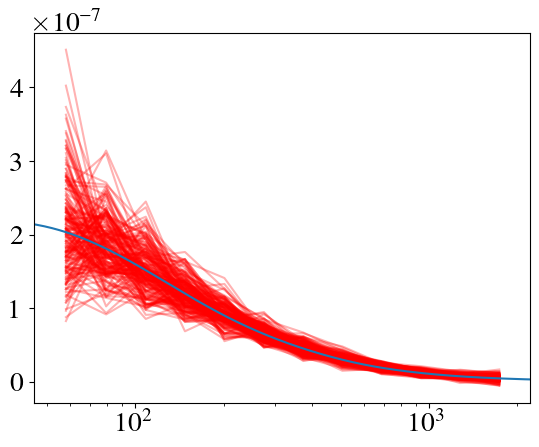

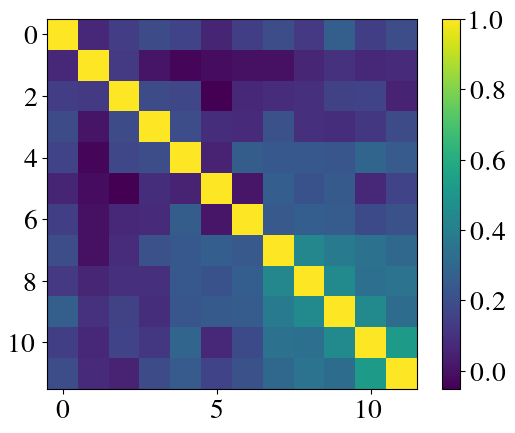

A_best:  1.006640425704836 0.07791058884757418
Chi2/dof = 0.8521401749014704
PTE = 0.5874546208013932
SNR:  [3.37090425 3.23056095 5.50348493 5.50612419 6.32747854 7.08010345
 6.34021417 4.57848475 5.68949506 2.34087758 1.07734907 1.05629887]
Field:  summer-b


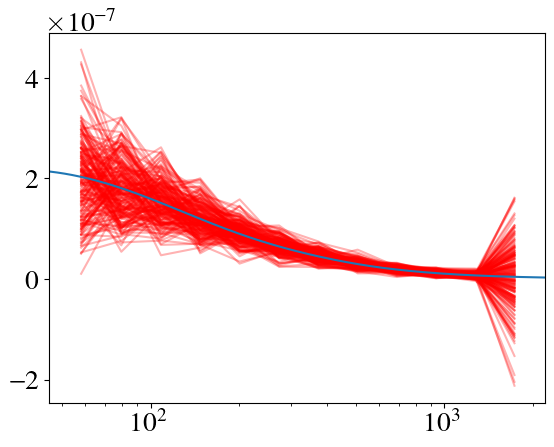

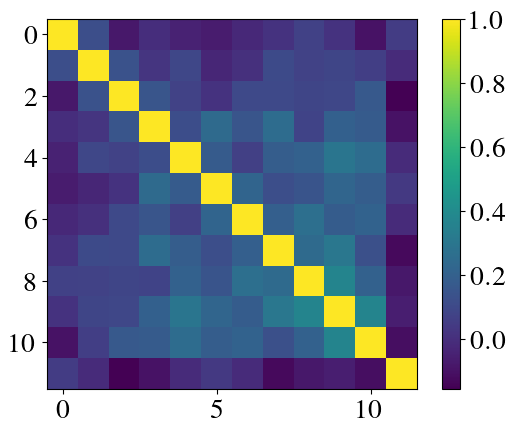

A_best:  0.8795302123048604 0.11490568657207778
Chi2/dof = 1.0426434944414416
PTE = 0.4048421066934772
SNR:  [ 2.07782581  2.17073419  2.47297182  3.44992071  3.96585699  3.58090287
  4.46182963  5.62003968  2.42632199  1.56515452  2.29213726 -0.96811957]
Field:  summer-c


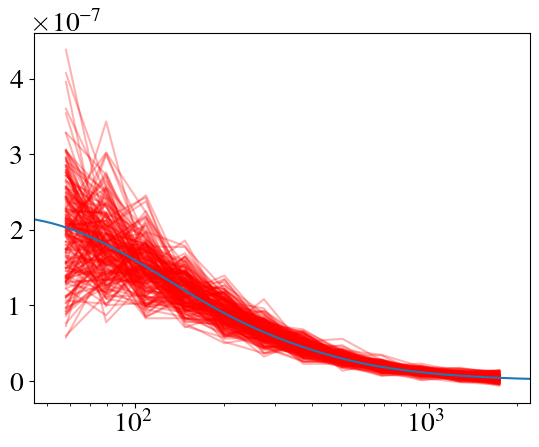

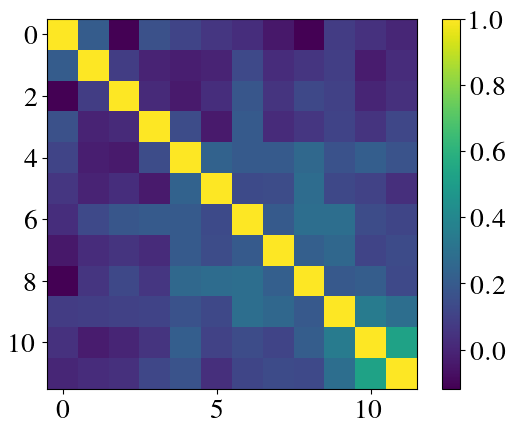

A_best:  1.073183834884461 0.09297394151177742
Chi2/dof = 0.4773000734627807
PTE = 0.9184410824493479
SNR:  [3.33462783 4.37272764 6.36903854 4.98615017 4.86170988 5.62399499
 4.41097497 4.90872953 3.91495591 4.16330634 1.39631697 0.96914785]
Field:  combined
A_best =  1.0012242536559999 0.05298749031327047
Chi2/dof = 0.7948125100427685
PTE = 0.8006790674243928


In [28]:
baseline_dic = {}
for field in field_arr:
    baseline_dir = '/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/' %(field) 
    baseline_dic[field] = baseline_dir

clkk0_dic = {}
clkk1_dic = {}
fkk_dic = {}
N0_dic = {}
RDN0_dic = {}
N1_dic = {}
clkk_mf_norm_avg_dic = {}
fMC_dic = {} 

for field in field_arr:    
    clkk0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_0a_0a_0a_0a.npz')['cls'].T[1][:Lmax]
    fkk_dic[field] =  np.load(baseline_dic[field]+'spectra/healpy/fkk_avg.npy')[:Lmax]
    N0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/N0_avg.npy')[:Lmax]
    RDN0_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/RDN0_avg.npy')[:Lmax]
    N1_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/N1_avg.npy')[:Lmax]
    clkk_mf_norm_avg_dic[field] = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_mf_mf_mf_mf.npz')['cls'].T[1][:Lmax]
    fMC_dic[field] = clkk_theory/(fkk_dic[field]-N0_dic[field]-N1_dic[field])

# binned lensing spectra
ell0_dic = {}
cl0_dic = {}

for field in field_arr:
    ell0_dic[field], cl0_dic[field], _ =logrebincl(ell, (clkk0_dic[field]-RDN0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell) 
        
cl_err_dic = {}
cov_dic = {}
A_best_arr = []
for field in field_arr:
    print("Field: ", field)
    cl_arr = []
    weights_arr = []
    for i in range(1, nsims+1):
        clkk = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]
        bins,cl, _ =logrebincl(np.arange(len(clkk)), (clkk-N0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell) 
        cl_arr.append(cl) 
        plt.plot(bins, cl, color='red', alpha=0.3)
    plt.xscale('log')
    plt.xlim(4.5e1, 2.2e3)
    plt.plot(clkk_theory)
    plt.show()    
    cov = np.cov(np.asarray(cl_arr).T)
    cov_dic[field] = cov
    corr = np.corrcoef(np.asarray(cl_arr).T)
    plt.imshow(corr)
    plt.colorbar()
    plt.show()

    cl_err_dic[field] = np.sqrt(np.diag(cov))

    # Best-fit amplitude
    cinv = np.linalg.inv(cov)
    A_best = clkkb_theory @ cinv @ cl0_dic[field] / (clkkb_theory @ cinv @ clkkb_theory)
    A_best_arr.append(A_best)
    A_err  = 1.0 / np.sqrt(clkkb_theory @ cinv @ clkkb_theory)
    print("A_best: ", A_best, A_err)
    residual = cl0_dic[field] - A_best * clkkb_theory
    chi2_val = residual @ cinv @ residual
    dof = len(cl0_dic[field]) - 1
    print("Chi2/dof =", chi2_val/dof)
    pte = 1 - chi2.cdf(chi2_val, dof)
    print("PTE =", pte)

    print("SNR: ", cl0_dic[field]/cl_err_dic[field])


cl0_comb = np.zeros(Nbins)
cl_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([cl0_dic['summer-a'][i],cl0_dic['summer-b'][i],cl0_dic['summer-c'][i]])
    sig=np.asarray([cl_err_dic['summer-a'][i],cl_err_dic['summer-b'][i],cl_err_dic['summer-c'][i]])
    cl0_comb[i] = np.sum(sig**(-2)*spec)/np.sum(sig**(-2))
    cl_err_comb[i] = (1/np.sum(sig**-2))**0.5

print("Field: ", 'combined')
A_best_comb, A_err_comb = combine_lensing_amplitude(cl0_dic, clkkb_theory, err_dic=None, cov_dic=cov_dic)
print("A_best = ", A_best_comb, A_err_comb)
chi2_tot, dof, pte = chi2_pte_combined(cl0_dic, clkkb_theory, cov_dic, A_best_comb)
print("Chi2/dof =", chi2_tot/dof)
print("PTE =", pte)

# amplitudes
ell0_dic = {}
amp0_dic = {}
delta_dic = {}
for field in field_arr:
    ell0_dic[field], cl0b, _ =logrebincl(ell, (clkk0_dic[field]-RDN0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell)  
    amp0_dic[field] = cl0b/clkkb_theory
    
amp_err_dic = {}
for field in field_arr:
    amp_arr = []
    for i in range(1, nsims+1):
        clkk = np.load(baseline_dic[field]+'spectra/healpy/clkk_TT_%sa_%sa_%sa_%sa.npz'%(i,i,i,i))['cls'].T[1][:Lmax]
        _,clkkb, _ =logrebincl(np.arange(len(clkk)), (clkk-N0_dic[field]-N1_dic[field])*fMC_dic[field], Nbins, minell, maxell)
        amp_arr.append(clkkb/clkkb_theory) 

    cov = np.cov(np.asarray(amp_arr).T)
    amp_err_dic[field] = np.sqrt(np.diag(cov))

amp0_comb = np.zeros(Nbins)
amp_err_comb = np.zeros(Nbins)

for i in range(Nbins):
    spec = np.asarray([amp0_dic['summer-a'][i], amp0_dic['summer-b'][i], amp0_dic['summer-c'][i]])
    sig = np.array([amp_err_dic['summer-a'][i],amp_err_dic['summer-b'][i],amp_err_dic['summer-c'][i]])
    weights = 1.0 / sig**2
    amp0_comb[i] = np.sum(weights * spec) / np.sum(weights)
    amp_err_comb[i] = np.sqrt(1.0 / np.sum(weights))

In [29]:
def bins(ell, Nbins=None, minell=None, maxell=None, bins=None, wl=None):
    ''' rebin cls in logspace '''
    if bins is None:
        bb = np.logspace(np.log10(minell),np.log10(maxell),Nbins+1)
        ll = (bb[:-1]).astype(np.int_)+1
        uu = (bb[1:]).astype(np.int_)
        print(ll)
        print(uu)
    else:
        ll = bins[0] 
        uu = bins[1] 
        Nbins = len(bins[0])

    retl = np.zeros(Nbins)
   
    for i in range(0,Nbins):
        retl[i] = np.mean(ell[ll[i]:uu[i]])
    print(retl)

print('Bins')
bin_ctr = bins(ell, Nbins=12, minell=50, maxell=2000)

print('Clkk')
for field in field_arr:
    print(field+':')
    print(np.round(cl0_dic[field]*1e7,3))
    print(np.round(cl_err_dic[field]*1e7, 3))

print('combined:')
print(np.round(cl0_comb*1e7, 3))
print(np.round(cl_err_comb*1e7,3))

Bins
[  50   68   93  126  171  233  317  431  585  796 1082 1471]
[  67   92  125  170  232  316  430  584  795 1081 1470 2000]
[  58.    79.5  108.5  147.5  201.   274.   373.   507.   689.5  938.
 1275.5 1735. ]
Clkk
summer-a:
[2.096 1.285 1.703 1.136 0.905 0.678 0.499 0.257 0.217 0.079 0.032 0.042]
[0.622 0.398 0.309 0.206 0.143 0.096 0.079 0.056 0.038 0.034 0.029 0.04 ]
summer-b:
[ 1.664  1.257  1.017  1.072  0.831  0.54   0.477  0.425  0.131  0.073
  0.1   -0.623]
[0.801 0.579 0.411 0.311 0.209 0.151 0.107 0.076 0.054 0.047 0.044 0.643]
summer-c:
[2.225 1.993 2.071 1.155 0.865 0.71  0.416 0.309 0.192 0.154 0.05  0.043]
[0.667 0.456 0.325 0.232 0.178 0.126 0.094 0.063 0.049 0.037 0.035 0.045]
combined:
[2.036 1.52  1.681 1.13  0.876 0.659 0.468 0.314 0.189 0.104 0.052 0.041]
[0.396 0.266 0.197 0.138 0.098 0.068 0.053 0.037 0.026 0.022 0.02  0.03 ]


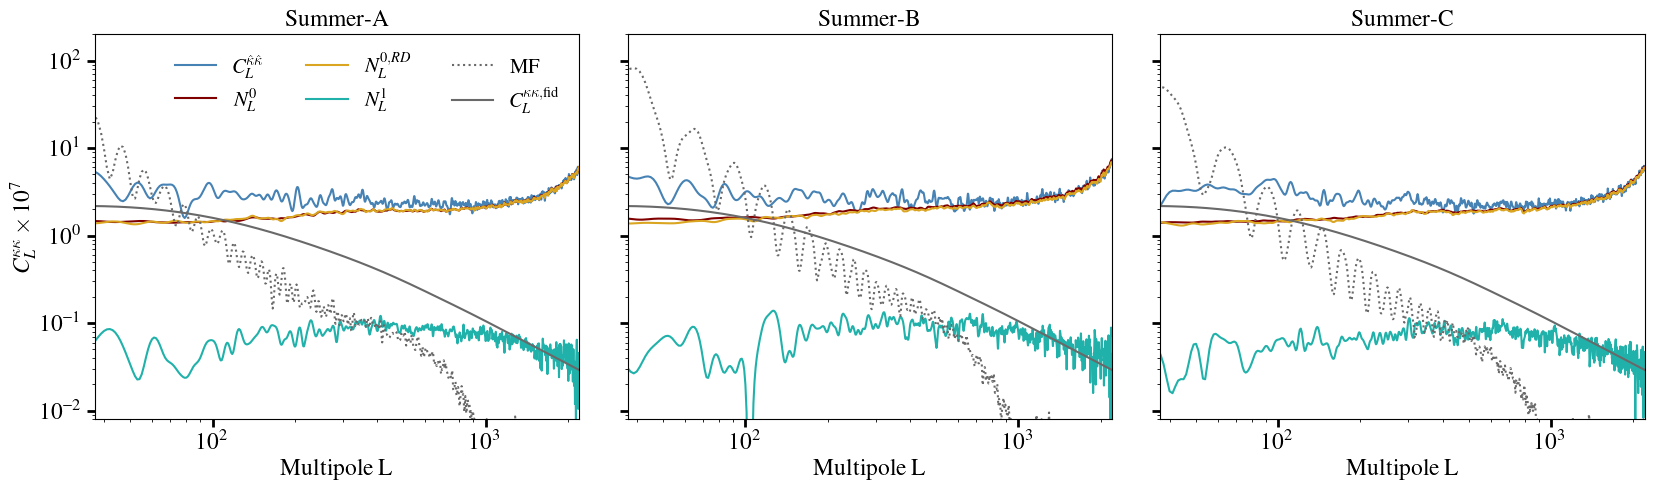

In [30]:
fig, ax_arr = plt.subplots(1, len(field_arr), sharey=True, figsize=(20,5))
plt.subplots_adjust(hspace=0.2, wspace = 0.1)

for cntr, field in enumerate(field_arr):


    ax_arr[cntr].plot(np.arange(len(clkk0_dic[field])), (clkk0_dic[field])*1e7, color=color_arr[0] , label=r'$C_{L}^{\hat{\kappa}\hat{\kappa}}$')
    ax_arr[cntr].plot(np.arange(len(N0_dic[field])), N0_dic[field]*1e7, color='maroon', label=r'$N_L^{0}$')
    ax_arr[cntr].plot(np.arange(len(RDN0_dic[field])), RDN0_dic[field]*1e7, color=color_arr[1], label=r'$N_L^{0, RD}$')
    ax_arr[cntr].plot(np.arange(len(N1_dic[field])), N1_dic[field]*1e7, color=color_arr[2], label=r'$N_L^{1}$')
    #ax_arr[cntr].plot(np.arange(len(fMC_dic[field])), fMC_dic[field]*1e7, color=color_arr[3], label=r'MC')
    ax_arr[cntr].plot(np.arange(len(clkk_mf_norm_avg_dic[field])), clkk_mf_norm_avg_dic[field]*1e7, label = 'MF', ls =':', color = color_arr[-1])

    ax_arr[cntr].plot(np.arange(len(clkk_theory)), clkk_theory*1e7, label = r'$C_{L}^{\kappa\kappa, \rm fid}$', color = color_arr[-1])

    ax_arr[cntr].set_xscale('log')
    ax_arr[cntr].set_yscale('log')
    ax_arr[cntr].set_xlim(3.7e1, 2.2e3)
    ax_arr[cntr].set_xlabel(r'Multipole L', fontsize=labelsize)
    
    ax_arr[cntr].set_title(title_dic[field], fontsize=labelsize) 
    ax_arr[cntr].tick_params(labelsize = labelsize, length = 6, width = 2)
 
    if cntr==0:
        ax_arr[cntr].set_ylim(8e-3, 2e2)
        ax_arr[cntr].set_ylabel(r'$C_L^{\kappa\kappa} \times 10^7$', fontsize=labelsize)
        ax_arr[cntr].legend(fontsize=legendsize, ncol=3, frameon=False)


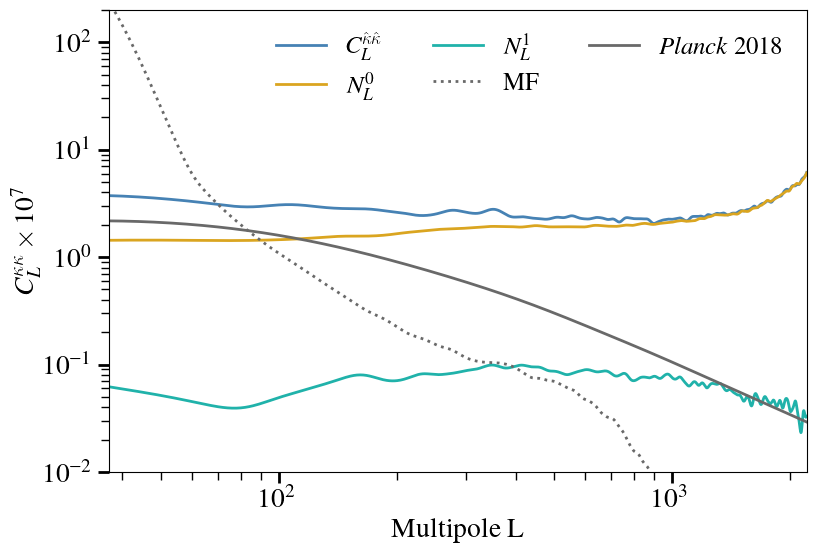

In [31]:
from scipy.ndimage import gaussian_filter1d
fig, ax = plt.subplots(figsize=(9,6))

field='summer-a'
linewidth=2
ax.plot(np.arange(len(clkk0_dic[field])), gaussian_filter1d(clkk0_dic[field], sigma=14)*1e7, color=color_arr[0] , label=r'$C_{L}^{\hat{\kappa}\hat{\kappa}}$', linewidth=linewidth)
ax.plot(np.arange(len(RDN0_dic[field])),gaussian_filter1d(N0_dic[field], sigma=14)*1e7, color=color_arr[1], label=r'$N_L^{0}$', linewidth=linewidth)
ax.plot(np.arange(len(N1_dic[field])), gaussian_filter1d(N1_dic[field], sigma=14)*1e7, color=color_arr[2], label=r'$N_L^{1}$', linewidth=linewidth)
ax.plot(np.arange(len(clkk_mf_norm_avg_dic[field])), gaussian_filter1d(clkk_mf_norm_avg_dic[field], sigma=14)*1e7, label = 'MF', ls =':', color = color_arr[-1], linewidth=linewidth)

ax.plot(np.arange(len(clkk_theory)), clkk_theory*1e7, label = r'\textit{Planck} 2018', color = color_arr[-1], linewidth=linewidth)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(3.7e1, 2.2e3)
ax.set_ylim(1e-2, 2e2)
ax.set_ylabel(r'$C_L^{\kappa\kappa} \times 10^7$', fontsize=labelsize+3.)
ax.set_xlabel(r'Multipole L', fontsize=labelsize+3.)
ax.legend(fontsize=legendsize+3., ncol=3, frameon=False) 
ax.tick_params(which='major', labelsize = labelsize+3., length = 8, width = 2)
ax.tick_params(which='minor', labelsize = labelsize+3., length = 6, width = 1)

plt.savefig(figures_dir+'raw_lensing_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)


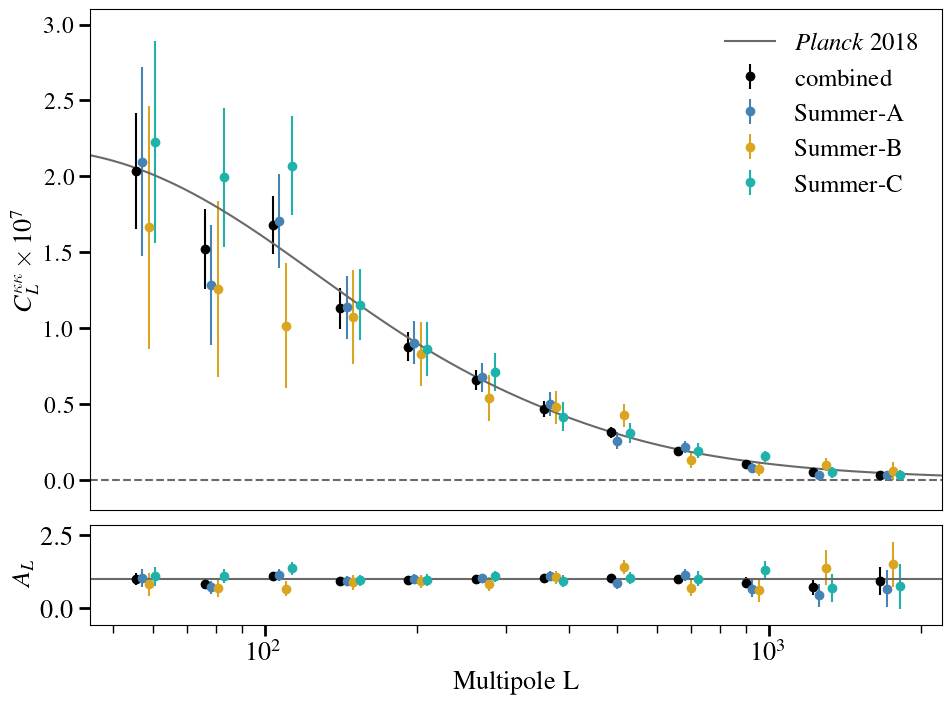

In [32]:
clkktheory = np.load('clkk_theory.npy')


fig, (ax1, ax2) = plt.subplots(ncols=1, nrows=2, figsize = (11.,8), constrained_layout=True, gridspec_kw={'height_ratios':[5,1]}) 
plt.subplots_adjust(hspace=0.05)

lensing = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_combined/sqe/spectra/bandpowers/lensing_bandpowers.npz")
ax1.errorbar(lensing['ell']/(log_offset**1.5), lensing['bandpowers']*1e7, yerr=np.sqrt(np.diag(lensing['covariance']))*1e7, marker = 'o', ls='None', color='black', label=r'combined')

title_arr = ['Summer-A', 'Summer-B', 'Summer-C']
for i, field in enumerate(field_arr):
    if field == 'summer-a':
        lensing = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/spectra/bandpowers/lensing_bandpowers.npz" %(field))
        ax1.errorbar(lensing['ell']/(log_offset**0.5), lensing['bandpowers']*1e7, yerr=np.sqrt(np.diag(lensing['covariance']))*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_arr[i])
    elif field == 'summer-b':
        lensing = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/spectra/bandpowers/lensing_bandpowers.npz" %(field))
        ax1.errorbar(lensing['ell']*(log_offset**(0.5+(i-1))), lensing['bandpowers']*1e7, yerr=np.sqrt(np.diag(lensing['covariance']))*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_arr[i])
    else:
        lensing = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_%s/sqe/spectra/bandpowers/lensing_bandpowers.npz" %(field))
        ax1.errorbar(lensing['ell']*(log_offset**(0.5+(i-1))), lensing['bandpowers']*1e7, yerr=np.sqrt(np.diag(lensing['covariance']))*1e7, marker = 'o', ls='None', color=color_arr[i], label=title_arr[i])

ax1.plot(np.arange(len(clkktheory)), clkktheory*1e7, label = r'\textit{Planck} 2018', color = color_arr[-1])
ax1.axhline(0, ls = '--', color = color_arr[-1])
ax1.set_xscale('log')
ax1.set_ylabel(r'$  C_L^{\kappa\kappa} \times 10^7 $', fontsize=labelsize+2)
ax1.legend(fontsize=labelsize+1, frameon=False)
ax1.tick_params(which='major', labelsize = labelsize, length = 8, width = 2)
ax1.tick_params(which='minor', labelsize = labelsize, length = 6, width = 1)
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False) 
ax1.set_ylim(-.2, 3.1)
ax1.set_xlim(4.5e1, 2.2e3)

ell0, amp0, amp_err = np.loadtxt('/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_combined/sqe/spectra/bandpowers/lensing_amplitudes.txt').T
ax2.errorbar(ell0/(log_offset**1.5), amp0, yerr=amp_err, marker = 'o', ls='None', color='black')

for i, field in enumerate(field_arr):
    if field == 'summer-a':
        ell0, amp0, amp_err = np.loadtxt('/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_summer-a/sqe/spectra/bandpowers/lensing_amplitudes.txt').T 
        ax2.errorbar(ell0/(log_offset**0.5), amp0, yerr=amp_err, marker = 'o', ls='None', color=color_arr[i])
    elif field == 'summer-b':
        ell0, amp0, amp_err = np.loadtxt('/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_summer-b/sqe/spectra/bandpowers/lensing_amplitudes.txt').T 
        ax2.errorbar(ell0*(log_offset**(0.5+(i-1))), amp0, yerr=amp_err, marker = 'o', ls='None', color=color_arr[i])
    else:
        ell0, amp0, amp_err = np.loadtxt('/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_summer-c/sqe/spectra/bandpowers/lensing_amplitudes.txt').T 
        ax2.errorbar(ell0*(log_offset**(0.5+(i-1))), amp0, yerr=amp_err, marker = 'o', ls='None', color=color_arr[i])

ax2.axhline(1, color = color_arr[-1])

ax2.tick_params(which='major', labelsize = labelsize+2, length = 8, width = 2)
ax2.tick_params(which='minor', labelsize = labelsize+2, length = 6, width = 1)
ax2.set_xlabel('Multipole L', fontsize=labelsize+2)
ax2.set_ylabel(r'$A_{L}$', fontsize=labelsize+2) 
ax2.set_ylim(-0.6, 2.85)
ax2.set_xlim(4.5e1, 2.2e3)
ax2.set_xscale('log')

plt.savefig(figures_dir+'binned_lensing_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

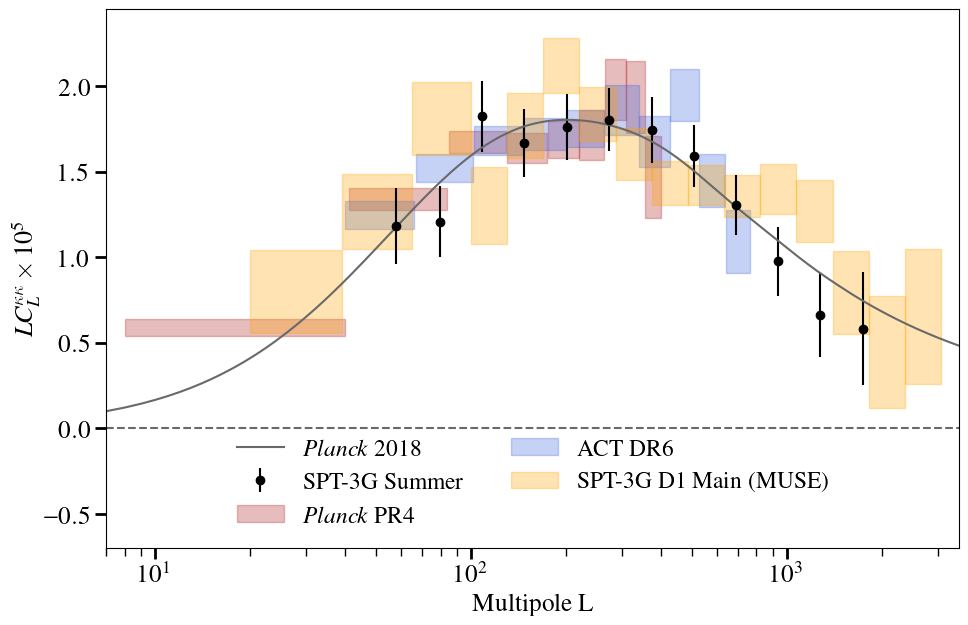

In [33]:
Lmin_carron22 = [8, 41, 85,  130, 175, 220, 265, 310, 355]
Lmax_carron22 = [40, 84, 129, 174, 219, 264, 309, 354, 400]
bins_carron22 = [28.1, 63.5, 106.2, 150.4, 195.1, 240.3, 285.8, 331.4, 377.3]
clkk_carron22 = np.asarray([1.40*0.95, 1.28*1.05, 0.993*1.01, 0.762*0.91, 0.599*0.92, 0.484*0.94, 0.401*1.10, 0.338*1.10, 0.288*0.86])*1e-2*np.pi/2*bins_carron22
err_carron22 = np.asarray([1.40*0.08, 1.28*0.05,0.993*0.04, 0.762*0.05, 0.599*0.06,  0.484*0.08, 0.401*0.10, 0.338*0.12, 0.288*0.14])*1e-2*np.pi/2*bins_carron22


Lmin_qu24 = [40, 67, 102,  146, 200, 265, 340, 427, 527, 639]
Lmax_qu24 = [66, 101, 145, 199, 264, 339, 426, 526, 638, 763]
bins_qu24 = [53, 83.5, 123, 172, 231.5, 301.5, 382.5, 476, 582, 700.5]
clkk_qu24 = np.asarray([2.354, 1.822, 1.368, 1.000, 0.758, 0.617, 0.439, 0.409, 0.249, 0.156])*bins_qu24*1e-2
err_qu24 =  np.asarray([0.157, 0.096, 0.068, 0.054, 0.047, 0.048, 0.039, 0.032, 0.027, 0.026])*bins_qu24*1e-2


bins = np.load("muse_likelihood.npz")['bpwf']
binmat = bins[0:None,:]
pells = np.arange(1, binmat.shape[1]+1)
Lmin_fei25 = np.array([pells[row > 0][0] for row in binmat])
Lmax_fei25 = np.array([pells[row > 0][-1] for row in binmat])
bins_fei25 = binmat@pells
clkk_fei25 = np.load("muse_likelihood.npz")['d_kk']*1e5*bins_fei25
covkk = np.load("muse_likelihood.npz")['cov_kk']
err_fei25 = np.sqrt(np.diag(covkk))*1e5*bins_fei25


Lmin_comp = [Lmin_carron22, Lmin_qu24, Lmin_fei25]
Lmax_comp = [Lmax_carron22, Lmax_qu24, Lmax_fei25]
bins_comp = [bins_carron22, bins_qu24, bins_fei25]
clkk_comp = [clkk_carron22, clkk_qu24, clkk_fei25]
err_comp = [err_carron22, err_qu24, err_fei25]
color_comp = [ 'firebrick', 'royalblue', 'orange', 'seagreen',  'darkorchid', 'silver']

clkktheory = np.load('clkk_theory.npy')

fig, ax = plt.subplots(figsize = (11,7.)) 

for i in range(len(clkk_comp)):
    for L1, L2, val, e in zip(Lmin_comp[i], Lmax_comp[i], clkk_comp[i], err_comp[i]):
        width = L2 - L1
        height = 2 * e
        rect = Rectangle((L1, val - e), width, height, color=color_comp[i], alpha=0.3, edgecolor=color_comp[i])
        ax.add_patch(rect)

lensing = np.load("/sptlocal/analysis/summer_fields_2y/lensing/healqest/lensrec/lensrec_lmin500lmax3000mmin100_combined/sqe/spectra/bandpowers/lensing_bandpowers.npz")
ax.errorbar(lensing['ell'], ell0*lensing['bandpowers']*1e5, yerr=ell0*np.sqrt(np.diag(lensing['covariance']))*1e5, marker = 'o', ls='None', color='black', label=r'SPT-3G Summer')
ax.plot(np.arange(len(clkktheory)), np.arange(len(clkktheory))*clkktheory*1e5, label = r'\textit{Planck} 2018', color = color_arr[-1])

proxy_carron22 = Rectangle((0,0), 1, 1, facecolor=color_comp[0], alpha=0.3, edgecolor=color_comp[0])
proxy_qu24 = Rectangle((0,0), 1, 1, facecolor=color_comp[1], alpha=0.3, edgecolor=color_comp[1])
proxy_fei25 = Rectangle((0,0), 1, 1, facecolor=color_comp[2], alpha=0.3, edgecolor=color_comp[2])
handles, labels = ax.get_legend_handles_labels()
handles.append(proxy_carron22)
handles.append(proxy_qu24)
handles.append(proxy_fei25)
labels.append('\emph{Planck} PR4')
labels.append('ACT DR6')
labels.append('SPT-3G D1 Main (MUSE)')

ax.axhline(0, ls='--', color=color_arr[-1])
ax.set_xscale('log')
ax.legend(handles, labels, frameon=False, loc='lower center', ncol=2, fontsize=labelsize)
ax.set_ylabel(r'$  L C_L^{\kappa\kappa} \times 10^5 $', fontsize=labelsize+2)
ax.set_xlabel('Multipole L', fontsize=labelsize+1.3)
ax.tick_params(which='major', labelsize = labelsize+1.3, length = 8, width = 2)
ax.tick_params(which='minor', labelsize = labelsize+1.3, length = 6, width = 1)
ax.set_ylim(-0.7, 2.45)
ax.set_xlim(7e0, 3.5e3)


plt.savefig(figures_dir+'comparison.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)